# **XGBoost Pipeline: LendingClub**

**Clean, end-to-end pipeline:** 
-> load 
-> target 
-> leakage drop  
-> feature engineering 
-> splits (random + OOT)
-> XGBoost baseline 
-> Optuna tuning 
-> evaluation 
-> SHAP interpretation.

## **1. Problem Framing**

**Goal:** predict whether a LendingClub loan will default, using only information available at the moment of application, so the model could support an accept/reject decision in the real world.

**Why it matters:** lending is asymmetric. A default loses most of the principal, while a good loan earns only a few percent interest. Even a small improvement in ranking risk at origination has a large effect on portfolio losses.

**Target:** a binary 12-month default flag. A loan is bad (1) if it reaches a terminal bad status (Charged Off / Default) within 12 months of origination, and good (0) if it survives the first 12 months without defaulting (or is fully repaid). Loans without a full 12-month window observed are excluded, since the outcome is not yet known. The overall default rate under this definition is about 5%

**Approach:**
- **XGBoost** is the model, chosen for tabular data and native handling of missing values. 
- **Feature engineering**: text-encoded fields are converted to numbers (`term`, `emp_length`), `earliest_cr_line` becomes a credit-history length, application_type becomes a binary flag, low-cardinality categories are one-hot encoded, and the high-cardinality `addr_state` is target-encoded inside the model pipeline so it is fit on training data only.
- Two evaluation splits: a **random** split (optimistic, same era) and a **time-based / out-of-time** split (trains on older loans, tests on newer ones, mimicking real deployment). Comparing them shows how well the model generalises across time.
- **Hyperparameter tuning with Optuna**: the XGBoost hyperparameters are searched with Optuna, using **StratifiedKFold** cross-validation inside the training set so the default rate is preserved across folds and the test set stays untouched.
- **Class imbalance (~5% default):** headline metrics are **AUC and PR-AUC** (with Gini alongside), not accuracy.
- **SHAP interpretation**: explain the tuned model both globally (which features drive risk) and per-loan (why an individual loan scores as it does), which is essential for a lending decision that must be justifiable.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
RANDOM_STATE = 42

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data" / "lendingclub"
LC_LOAN_PATH = DATA_DIR / "lc_loan.csv"
LC_2016_PATH = DATA_DIR / "lc_2016_2017.csv"

sns.set_theme(style="whitegrid")

## **2. Data Understanding**

### **2.1 Data Inventory**

### **2.1.1 Files listing and sizes**

In [3]:
# Confirm the data folder exists and list contents with file sizes
# (DATA_DIR is defined in the config cell at the top of the notebook)
assert DATA_DIR.exists(), f"Data folder not found at {DATA_DIR.resolve()}"

print(f"{'File':<35} {'Size (MB)':>10}")
print("-" * 47)
for f in sorted(DATA_DIR.iterdir()):
    size_mb = f.stat().st_size / 1e6
    print(f"{f.name:<35} {size_mb:>10.1f}")

File                                 Size (MB)
-----------------------------------------------
LCDataDictionary.xlsx                      0.0
lc_2016_2017.csv                         282.7
lc_loan.csv                              441.8
new.html                                   0.0
us-state-codes.csv                         0.0


### **2.1.2 Inspect 'lc_loan.csv' and 'lc_2016_2017.csv' files**

In [4]:
# Load only first 5 rows of lc_loan.csv and lc_2016_2017.csv to confirm structure and column names
lc_loan_preview = pd.read_csv(DATA_DIR / "lc_loan.csv", nrows=5, low_memory=False)
lc_2016_2017_preview = pd.read_csv(DATA_DIR / "lc_2016_2017.csv", nrows=5, low_memory=False)

print(f"lc_loan.csv: first 5 rows")
print(f"  Shape (preview): {lc_loan_preview.shape}")
display(lc_loan_preview)

print(f"\nlc_2016_2017.csv: first 5 rows")
print(f"  Shape (preview): {lc_2016_2017_preview.shape}")
display(lc_2016_2017_preview)

lc_loan.csv: first 5 rows
  Shape (preview): (5, 74)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,1077501,1296599,5000.0,5000.0,4975.0,36 months,10.65,162.87,B,B2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1077430,1314167,2500.0,2500.0,2500.0,60 months,15.27,59.83,C,C4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1077175,1313524,2400.0,2400.0,2400.0,36 months,15.96,84.33,C,C5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1076863,1277178,10000.0,10000.0,10000.0,36 months,13.49,339.31,C,C1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1075358,1311748,3000.0,3000.0,3000.0,60 months,12.69,67.79,B,B5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



lc_2016_2017.csv: first 5 rows
  Shape (preview): (5, 72)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,112435993,NaN,2300,2300,2300,36 months,12.62,77.08,C,C1,...,0,NaN,1,2,2315,55,7100,1,0,2
1,112290210,NaN,16000,16000,16000,60 months,12.62,360.95,C,C1,...,11078,69.0,3,5,1962,94,31900,0,6,1
2,112436985,NaN,6025,6025,6025,36 months,15.05,209.01,C,C4,...,0,NaN,1,2,1950,45,27700,1,5,3
3,112439006,NaN,20400,20400,20400,36 months,9.44,652.91,B,B1,...,53566,95.0,1,2,4240,60,46900,1,1,1
4,112438929,NaN,13000,13000,13000,36 months,11.99,431.73,B,B5,...,8466,72.0,0,1,2996,78,7800,0,0,0


#### - **Full shape of each file (rows × columns)**

In [5]:
# Load the full files to get exact row counts and shapes.
lc_loan = pd.read_csv(DATA_DIR / "lc_loan.csv", low_memory=False)
print(f"lc_loan.csv:        {lc_loan.shape[0]:>10,} rows x {lc_loan.shape[1]:>3} columns")

lc_2016_2017 = pd.read_csv(DATA_DIR / "lc_2016_2017.csv", low_memory=False)
print(f"lc_2016_2017.csv:   {lc_2016_2017.shape[0]:>10,} rows x {lc_2016_2017.shape[1]:>3} columns")

print(f"\nCombined:           {lc_loan.shape[0] + lc_2016_2017.shape[0]:>10,} rows total")

lc_loan.csv:           887,379 rows x  74 columns
lc_2016_2017.csv:      759,338 rows x  72 columns

Combined:            1,646,717 rows total


### - Schema comparison: do the two CSVs share columns?

In [6]:
# Get column sets from each file
cols_main = set(lc_loan.columns)
cols_2016_2017 = set(lc_2016_2017.columns)

# Identify differences
only_in_main = cols_main - cols_2016_2017
only_in_2016_2017 = cols_2016_2017 - cols_main
in_both = cols_main & cols_2016_2017

print(f"Columns in lc_loan.csv only:       {len(only_in_main)}")
print(f"Columns in lc_2016_2017.csv only:  {len(only_in_2016_2017)}")
print(f"Columns in both files:              {len(in_both)}")

if only_in_main:
    print(f"\nIn lc_loan.csv but NOT in lc_2016_2017.csv:")
    for col in sorted(only_in_main):
        print(f"  - {col}")

if only_in_2016_2017:
    print(f"\nIn lc_2016_2017.csv but NOT in lc_loan.csv:")
    for col in sorted(only_in_2016_2017):
        print(f"  - {col}")

Columns in lc_loan.csv only:       2
Columns in lc_2016_2017.csv only:  0
Columns in both files:              72

In lc_loan.csv but NOT in lc_2016_2017.csv:
  - open_il_6m
  - url


#### - **Date range of each file (overlap check)**

In [7]:
# Parse issue_d to datetime for both files
lc_loan['issue_d'] = pd.to_datetime(lc_loan['issue_d'], format='%b-%Y', errors='coerce')
lc_2016_2017['issue_d'] = pd.to_datetime(lc_2016_2017['issue_d'], format='%b-%Y', errors='coerce')

print("Date ranges per file:")
print(f"  lc_loan.csv:        {lc_loan['issue_d'].min()} to {lc_loan['issue_d'].max()}")
print(f"  lc_2016_2017.csv:   {lc_2016_2017['issue_d'].min()} to {lc_2016_2017['issue_d'].max()}")

# Check for overlap
overlap_start = max(lc_loan['issue_d'].min(), lc_2016_2017['issue_d'].min())
overlap_end = min(lc_loan['issue_d'].max(), lc_2016_2017['issue_d'].max())

if overlap_start <= overlap_end:
    overlap_rows_main = ((lc_loan['issue_d'] >= overlap_start) & (lc_loan['issue_d'] <= overlap_end)).sum()
    overlap_rows_2016_2017 = ((lc_2016_2017['issue_d'] >= overlap_start) & (lc_2016_2017['issue_d'] <= overlap_end)).sum()
    print(f"\nWARNING: Date ranges overlap from {overlap_start} to {overlap_end}")
    print(f"  Overlapping rows in lc_loan.csv:       {overlap_rows_main:,}")
    print(f"  Overlapping rows in lc_2016_2017.csv:  {overlap_rows_2016_2017:,}")
else:
    print(f"\nFiles cover non-overlapping date ranges - safe to concatenate.")

# Distribution of loans by year to see the temporal shape
print("\nLoan counts by issue year:")
combined_temp = pd.concat([
    lc_loan[['issue_d']].assign(source='lc_loan'),
    lc_2016_2017[['issue_d']].assign(source='lc_2016_2017')
])
combined_temp['year'] = combined_temp['issue_d'].dt.year
print(combined_temp.groupby(['year', 'source']).size().unstack(fill_value=0))

Date ranges per file:
  lc_loan.csv:        2007-06-01 00:00:00 to 2015-12-01 00:00:00
  lc_2016_2017.csv:   2016-01-01 00:00:00 to 2017-09-01 00:00:00

Files cover non-overlapping date ranges - safe to concatenate.

Loan counts by issue year:
source  lc_2016_2017  lc_loan
year                         
2007               0      603
2008               0     2393
2009               0     5281
2010               0    12537
2011               0    21721
2012               0    53367
2013               0   134755
2014               0   235628
2015               0   421094
2016          434407        0
2017          324931        0


#### - **Dtype summary**

In [8]:
print("Data type distribution in lc_loan.csv:")
print(lc_loan.dtypes.value_counts())
print()
print("Data type distribution in lc_2016_2017.csv:")
print(lc_2016_2017.dtypes.value_counts())

Data type distribution in lc_loan.csv:
float64           49
str               22
int64              2
datetime64[us]     1
Name: count, dtype: int64

Data type distribution in lc_2016_2017.csv:
float64           40
str               21
int64             10
datetime64[us]     1
Name: count, dtype: int64


### **2.1.3 Inspect us-state-codes.csv and new.html**

#### - **us-state-codes.csv**

In [9]:
# us-state-codes.csv: Preview first 10 rows and column names
us_states = pd.read_csv(DATA_DIR / "us-state-codes.csv")
print(f"us-state-codes.csv shape: {us_states.shape}")
print(us_states.head(10))
print(f"\nColumn names: {list(us_states.columns)}")


us-state-codes.csv shape: (57, 2)
  state_code        state
0      US-AL      Alabama
1      US-AK       Alaska
2      US-AZ      Arizona
3      US-AR     Arkansas
4      US-CA   California
5      US-CO     Colorado
6      US-CT  Connecticut
7      US-DE     Delaware
8      US-FL      Florida
9      US-GA      Georgia

Column names: ['state_code', 'state']


- us-state-codes.csv contains a simple 2-column mapping of state abbreviations to full names. This will be used later for state-level analysis or display purposes, but it's not required for modelling because addr_state in the main data is already the abbreviation that is needed.

#### - **new.html**

In [10]:
# new.html: peek at content to determine its role
with open(DATA_DIR / "new.html", "r", encoding="utf-8") as f:
    html_preview = f.read()

print(f"new.html size: {len(html_preview):,} characters")
print(f"\nFirst 500 characters:")
print(html_preview[:500])

new.html size: 5,329 characters

First 500 characters:
 <!-- GeoChart generated in R 3.4.2 by googleVis 0.6.2 package -->
 <!-- Thu Jun 28 07:27:57 2018 -->
 
 
 <!-- jsHeader -->
 <script type="text/javascript">
  
 // jsData 
 function gvisDataGeoChartID12f3f099d () {
 var data = new google.visualization.DataTable();
 var datajson =
 [
  [
 "US-AK",
 "Alaska- Defaulters:151",
 0.22
 ],
 [
 "US-AL",
 "Alabama- Defaulters:993",
 1.47
 ],
 [
 "US-AR",
 "Arkansas- Defaulters:507",
 0.75
 ],
 [
 "US-AZ",
 "Arizona- Defaulters:1581",
 2.34
 ],
 [
 "US-C


### **2.1.4 Combine the two loan files: lc_loan + lc_2016_2017**

In [11]:
# Combine the two loan files, keeping only shared columns
shared_columns = sorted(in_both)
# `_source` tags each row with its origin file. The two files were frozen at
# different times, so we need it later to judge each loan's 12-month window
# against the correct file's payment history. It is a helper, not a feature.
df = pd.concat([
    lc_loan[shared_columns].assign(_source='lc_loan'),
    lc_2016_2017[shared_columns].assign(_source='lc_2016_2017')
], ignore_index=True)

print(f"Combined dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns "
      f"({len(shared_columns)} shared + 1 source tag)")
print(f"Date range: {df['issue_d'].min()} to {df['issue_d'].max()}")

Combined dataset shape: 1,646,717 rows x 73 columns (72 shared + 1 source tag)
Date range: 2007-06-01 00:00:00 to 2017-09-01 00:00:00


### **Modelling dataset decision**

Based on the inventory above, the modelling dataset is constructed as follows:

- **Source files:** lc_loan.csv (2007-2015) + lc_2016_2017.csv (2016-2017)
- **Columns kept:** The 72 columns shared between both files. The 2 columns unique to lc_loan.csv (open_il_6m, url) are dropped for a unified schema.
- **Row handling:** Files are concatenated since their date ranges do not overlap.
- **Total dataset:** 1.65 million loans spanning 2007-2017.


**Implications:**
- The clean 2015/2016 boundary between files is convenient since it can serve as the time-based split 
- `us-state-codes.csv` will not be used for modelling; only for display in EDA if relevant
- A column data dictionary (`LCDataDictionary.xlsx`) is kept in `data/lendingclub/` for reference when interpreting fields.

### **2.1.5 String harmonisation**

- strip whitespace 
across all object columns to ensure consistent values.

In [12]:
object_cols = df.select_dtypes(include='str').columns.tolist()

# Audit: which columns have whitespace inconsistencies?
inconsistent_cols = []
for col in object_cols:
    before = df[col].nunique(dropna=True)
    after = df[col].str.strip().nunique(dropna=True)
    if before != after:
        inconsistent_cols.append(col)
        print(f"  {col}: {before} → {after} unique values after strip "
              f"({before - after} whitespace duplicates)")

# Apply strip to all object columns
for col in object_cols:
    df[col] = df[col].str.strip()

if inconsistent_cols:
    print(f"\nHarmonised {len(inconsistent_cols)} columns affected by whitespace inconsistencies.")
else:
    print("No whitespace inconsistencies detected.")

  desc: 124484 → 124468 unique values after strip (16 whitespace duplicates)
  emp_title: 424073 → 412474 unique values after strip (11599 whitespace duplicates)
  term: 4 → 2 unique values after strip (2 whitespace duplicates)
  title: 63143 → 61444 unique values after strip (1699 whitespace duplicates)

Harmonised 4 columns affected by whitespace inconsistencies.


### **2.2 Exploratory Data Analysis**

**Overall Goal:**
- Get an understanding for which variables are important, view summary statistics, and visualise the data
    - How does default behaviour vary across loan attributes, borrower attributes, and time?

### **2.2.1 Target variable**

The binary target for the model is derived from `loan_status`. The cell below shows the raw distribution of status values across the full dataset, before any mapping or filtering.

In [13]:
# Raw distribution of loan_status values
status_counts = df["loan_status"].value_counts(dropna=False)
status_pct = df["loan_status"].value_counts(dropna=False, normalize=True).mul(100).round(2)
pd.DataFrame({"count": status_counts, "pct": status_pct})

,count,pct
loan_status,,
Current,1167302,70.89
Fully Paid,338441,20.55
Charged Off,82445,5.01
Late (31-120 days),26945,1.64
In Grace Period,12887,0.78
Issued,8460,0.51
Late (16-30 days),6233,0.38
Does not meet the credit policy. Status:Fully Paid,1988,0.12
Default,1255,0.08


#### **Defining the target: 12-month default**

The mapping uses a **12-month default definition**: a loan is *bad* (`target = 1`) if it reaches a terminal bad status (`Charged Off`, `Default`) within 12 months of origination, and *good* (`target = 0`) otherwise.

**Why a fixed 12-month window rather than "ever defaulted"?** Loans have different terms (36 vs 60 months) and different amounts of elapsed time. The "ever defaulted" view gives older loans more chances to go bad and makes recent loans look artificially safe. A fixed window measures every loan over the same horizon.

The data has no default date, so the timing is approximated with `last_pymnt_d` (the last month a payment was received). 

**Two-step rule:**

1. **Eligibility (maturity).** A loan is kept only if its full 12-month window has been observed in its source file (`months_observed >= 12`). Loans issued within 12 months of the file snapshot are under-observed and cannot be labelled, so they are dropped. This removes the 2017 tail and the 2015 tail by the same rule (lc_loan was pulled ~Jan-2016, so most of 2015 has under 12 months of history).
2. **Label.** Among eligible loans, bad (`target = 1`) means the loan reached a terminal bad status (`Charged Off`, `Default`) and stopped paying within the first 12 months (timing via `last_pymnt_d`). Every other eligible loan survived the window and is good (`target = 0`).

Only the first 12 months count. A loan that defaults after month 12 (for example a 60-month loan that fails in month 25) is labelled good, because nothing bad happened inside the window.

*NOTE:* `last_pymnt_d` records the month of the borrower's last payment, not the official charge-off date. The charge-off itself usually happens a few months after payments stop, so "bad within 12 months" means the borrower stopped paying within the first 12 months.

In [14]:
# 12-month default target (two-step rule)
# STEP 1 decides which loans are ELIGIBLE (full 12-month window observed).
# STEP 2 labels the eligible loans on their FIRST 12 months only.
HORIZON = 12  # fixed performance window, in months

bad_statuses = [
    'Charged Off',
    'Default',
    'Does not meet the credit policy. Status:Charged Off',
]

# Parse last_pymnt_d (issue_d was parsed in the inventory step).
df['last_pymnt_d'] = pd.to_datetime(df['last_pymnt_d'], format='%b-%Y', errors='coerce')

# Each source file is a snapshot frozen at a different time. Using each file's own
# latest payment month as its cut-off keeps a loan's window judged only against its
# own file's history.
file_snapshot = df.groupby('_source')['last_pymnt_d'].transform('max')

# months_observed: how many months of this loan are visible in its file.
df['months_observed'] = (
    (file_snapshot.dt.year  - df['issue_d'].dt.year) * 12
    + (file_snapshot.dt.month - df['issue_d'].dt.month)
)

# months_to_last_pymnt: proxy for when the loan stopped paying (when it went bad).
df['months_to_last_pymnt'] = (
    (df['last_pymnt_d'].dt.year  - df['issue_d'].dt.year) * 12
    + (df['last_pymnt_d'].dt.month - df['issue_d'].dt.month)
)

# STEP 1: Eligibility -> keep only loans observed for the full 12-month window.
# Loans issued within 12 months of their file snapshot are under-observed and
# cannot be labelled. This drops the 2017 tail and the 2015 tail by the same rule.
rows_before = len(df)
df = df[df['months_observed'] >= HORIZON].copy()

# STEP 2: Label 
# -> bad (1) = reached a terminal bad status AND stopped paying within the first 12 months. 
# -> good (0) = Every other eligible loan survived the window
df['target'] = (
    df['loan_status'].isin(bad_statuses) & (df['months_to_last_pymnt'] <= HORIZON)
).astype(int)

print(f"Eligible (at least 12m observed): {len(df):,} of {rows_before:,} ({len(df)/rows_before:.1%})")
print(df['target'].value_counts())
print(f"Default rate: {df['target'].mean():.2%}")

Eligible (at least 12m observed): 935,799 of 1,646,717 (56.8%)
target
0    885873
1     49926
Name: count, dtype: int64
Default rate: 5.34%


- Almost 711k loans are dropped, which are the under-observed loans

**Important caution:**
- The 5.34% of default rate is a 12-month default rate, not a lifetime rate.

- The 5.34% measures defaults within the first 12 months of origination. A loan that survives its first 12 months is labelled good, even if it later defaults (for example a 60-month loan that charges off in year 3). The true lifetime default rate is therefore higher than 5.34%.

- A fixed 12-month window keeps every vintage comparable and matches the modelling question ("Will this loan default in the next 12 months?"). The trade-off is that the model targets early default specifically, not eventual default. Capturing lifetime risk would need a longer window or a survival model, which is noted as a limitation.

The 12-month default rate above confirms class imbalance (about 5% default), which has two implications:

1. StratifiedKFold is used for cross-validation so each fold preserves the default rate.
2. AUC, PR-AUC, and Gini are the main evaluation metrics. Accuracy is misleading at this imbalance, since always predicting "non-default" would already score about 95%.

### **2.2.2 Default rate over time**

In [15]:
# Extract year from issue_d (already parsed to datetime in inventory step)
df['issue_year'] = df['issue_d'].dt.year

# Default rate by year, with counts
default_by_year = df.groupby('issue_year')['target'].agg(['count', 'mean']).reset_index()
default_by_year.columns = ['issue_year', 'loan_count', 'default_rate']
default_by_year

,issue_year,loan_count,default_rate
0,2007,603,0.096186
1,2008,2393,0.090263
2,2009,5281,0.058133
3,2010,12537,0.047699
4,2011,21721,0.048893
5,2012,53367,0.054528
6,2013,134755,0.047123
7,2014,235628,0.047278
8,2015,35107,0.027801
9,2016,434407,0.060563


**How to read this default rate table:**
- The default rate is a vintage rate, grouped by the year each loan was issued (issue_d), not by when anything happened to it later. Every loan belongs to exactly one row: its origination year.

- For example, a loan issued June 2013 is part of the 2013 vintage. Its 12-month window runs June 2013 to June 2014. If it reaches a bad status inside that window, it counts as a default for 2013; otherwise it counts as good for 2013. Even if it eventually charges off much later (say February 2015, around month 20), that falls outside the 12-month window, so it is still labelled good, and it still belongs to 2013. A loan never contributes to any year other than the one it was issued in.

- So each row answers: of all loans issued in that year (and eligible for a full 12-month window), what fraction defaulted within their own first 12 months.

**What the data shows (12-month default rate by vintage):**

With every loan judged over the same 12-month window and under-observed loans removed, the old maturity bias is gone.

- **2007-2014 and 2016** have **full 12-month windows**, so their rates are comparable and reflect real differences in credit quality across cohorts.

- **2017** is **dropped entirely**. lc_2016_2017 file was frozen around December 2017. A loan issued in January 2017 has only 11 months of history by then, and later 2017 loans have even less. No 2017 loan reaches a full 12 months, so the whole vintage is removed.

- **2015** is **mostly dropped, but not entirely**. lc_loan file was frozen around January 2016, only about a month after the last 2015 loans were issued. A loan issued in January 2015 just reaches 12 months by that snapshot and is kept; a loan issued February 2015 has only 11 months, June 2015 has 7, December 2015 has 1, so all of those are removed. Only the ~35k January-2015 loans survive. Their 2.78% rate is therefore a January-only figure, not a true full-year 2015 rate. These survivors have a known 12-month outcome, so they are validly labelled and stay in the data.

**What this means for modelling:** the out-of-time test set is the **2016** vintage (full windows). The training side spans 2007 through the small 2015 remnant; 2017 is excluded.

### **2.2.3 Default rate by loan attributes**

#### **2.2.3.1 By grade VS. sub_grade**
- grade: LC assigned loan grade
- sub_grade: LC assigned loan subgrade 

##### - **Unique grade and subgrade values** 

In [16]:
print(f"GRADE unique: {df.grade.unique()}")
print(f"SUB_GRADE unique: {df.sub_grade.unique()}")

GRADE unique: <StringArray>
['B', 'C', 'A', 'E', 'F', 'D', 'G']
Length: 7, dtype: str
SUB_GRADE unique: <StringArray>
['B2', 'C4', 'C5', 'C1', 'B5', 'A4', 'E1', 'F2', 'C3', 'B1', 'D1', 'A1', 'B3',
 'B4', 'C2', 'D2', 'A3', 'A5', 'D5', 'A2', 'E4', 'D3', 'D4', 'F3', 'E3', 'F4',
 'F1', 'E5', 'G4', 'E2', 'G3', 'G2', 'G1', 'F5', 'G5']
Length: 35, dtype: str


##### - **Loan Counts by grade and subgrade**

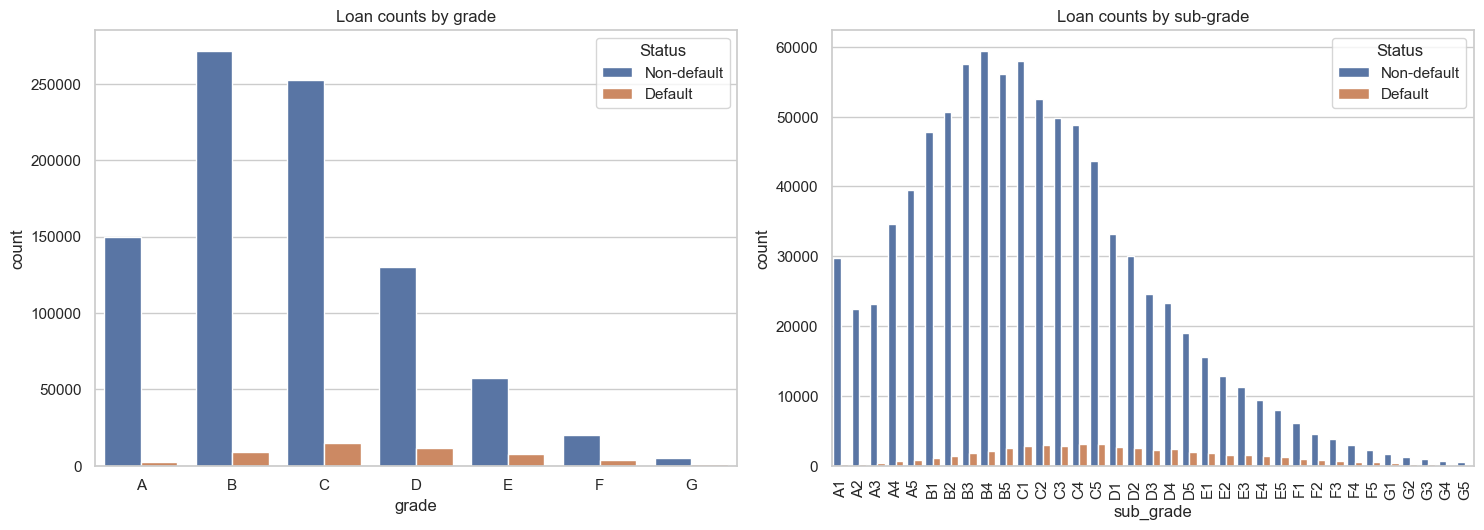

In [17]:
plt.figure(figsize=(15, 10))

# Loan counts by grade and default status
plt.subplot(2, 2, 1)
grade_order = sorted(df['grade'].dropna().unique())
sns.countplot(x='grade', data=df, hue='target', order=grade_order, hue_order=[0, 1])
plt.title('Loan counts by grade')
plt.legend(title='Status', labels=['Non-default', 'Default'])

# Loan counts by sub-grade and default status
plt.subplot(2, 2, 2)
subgrade_order = sorted(df['sub_grade'].dropna().unique())
ax = sns.countplot(x='sub_grade', data=df, hue='target', order=subgrade_order, hue_order=[0, 1])
ax.tick_params(axis='x', rotation=90)
plt.title('Loan counts by sub-grade')
plt.legend(title='Status', labels=['Non-default', 'Default'])

plt.tight_layout()
plt.show()


The higher grades make up most of the loans, while F and G are only a thin slice, so their bars are easy to miss next to A-C. The default share does grow toward the riskier grades, but at the F and G tail the bars are too small to read it clearly. Isolate F and G and recreate the count plot for just those subgrades to see the pattern.

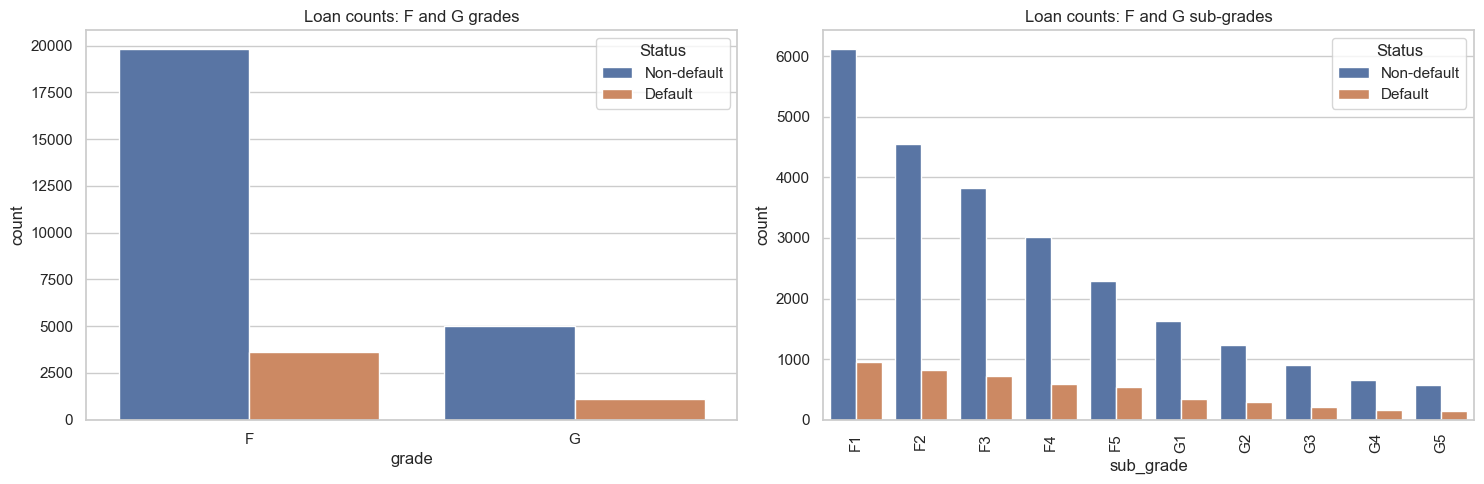

In [18]:
# Isolate F and G grades and recreate the count plots for just those
fg = df[df['grade'].isin(['F', 'G'])]

plt.figure(figsize=(15, 5))

# F/G by grade
plt.subplot(1, 2, 1)
grade_order = sorted(fg['grade'].unique())
sns.countplot(x='grade', data=fg, hue='target', order=grade_order, hue_order=[0, 1])
plt.title('Loan counts: F and G grades')
plt.legend(title='Status', labels=['Non-default', 'Default'])

# F/G by sub-grade
plt.subplot(1, 2, 2)
subgrade_order = sorted(fg['sub_grade'].unique())
ax = sns.countplot(x='sub_grade', data=fg, hue='target', order=subgrade_order, hue_order=[0, 1])
ax.tick_params(axis='x', rotation=90)
plt.title('Loan counts: F and G sub-grades')
plt.legend(title='Status', labels=['Non-default', 'Default'])

plt.tight_layout()
plt.show()


With F and G isolated on their own axis, the high default share is now clear: defaults take up a far larger slice of each bar than in the stronger grades. Loan volume falls steadily from F1 down to G5, yet the default proportion holds up across the whole tail and is largest at the deepest sub-grades. These are consistently the least reliable loans, just very few of them.

#### - **Default rate by grade and subgrade**

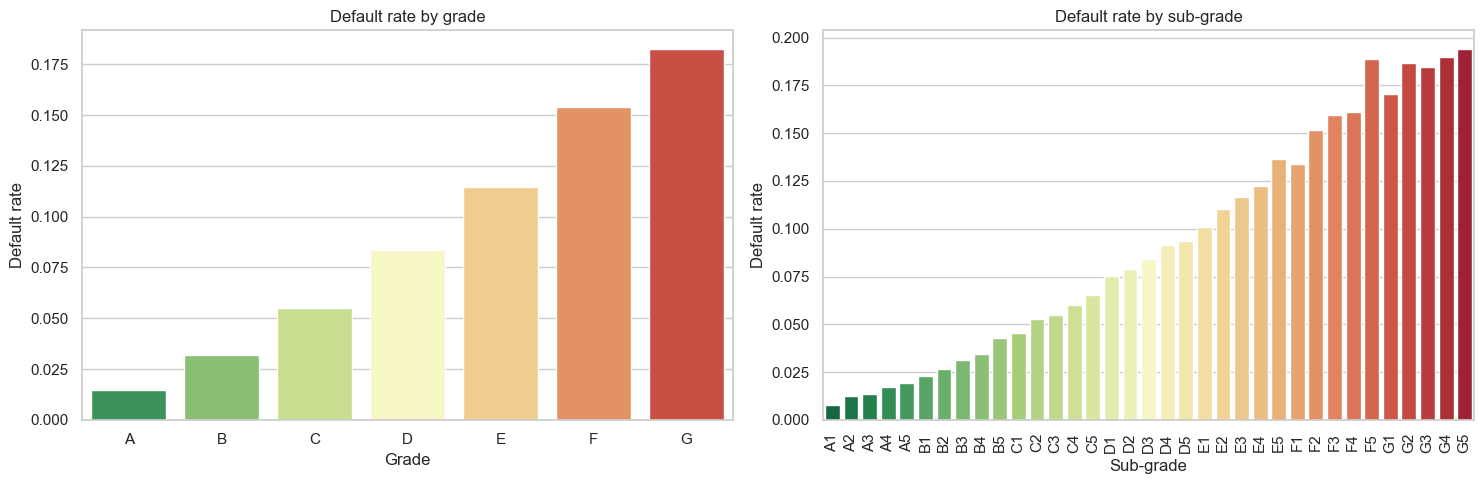

In [19]:
# Default rates by grade and sub-grade

plt.figure(figsize=(15, 5))

# Default rate by grade (left)
plt.subplot(1, 2, 1)
grade_rate = df.groupby('grade')['target'].mean().sort_index()
sns.barplot(x=grade_rate.index, y=grade_rate.values,
            hue=grade_rate.index, palette='RdYlGn_r', legend=False)
plt.title('Default rate by grade')
plt.xlabel('Grade')
plt.ylabel('Default rate')

# Default rate by sub-grade (right)
plt.subplot(1, 2, 2)
subgrade_rate = df.groupby('sub_grade')['target'].mean().sort_index()
ax = sns.barplot(x=subgrade_rate.index, y=subgrade_rate.values,
                 hue=subgrade_rate.index, palette='RdYlGn_r', legend=False)
ax.tick_params(axis='x', rotation=90)
plt.title('Default rate by sub-grade')
plt.xlabel('Sub-grade')
plt.ylabel('Default rate')

plt.tight_layout()
plt.show()


**Key observations:**

- Default rate climbs steadily from A to G, with no reversals at the grade level. This is the cleanest, most monotonic relationship of any feature in the data, confirming that LendingClub's grade ranks risk effectively.
- Sub-grade adds finer resolution, rising smoothly from A1 through to G5. The spread from the safest to the riskiest sub-grade is wide, so the ranking discriminates within each letter, not just between letters.
- The F and G tail is slightly noisy; a small dip and recovery rather than a perfectly smooth climb, which fits the small sample sizes seen in the count plot. The overall direction is still clearly upward.
- Because **grade and sub-grade** are LendingClub's own risk score, this strong, clean gradient is exactly why they **are excluded from the model as features**: using them would mean learning LC's prior decision rather than the borrower's raw attributes.


#### **2.2.3.2 By loan purpose**

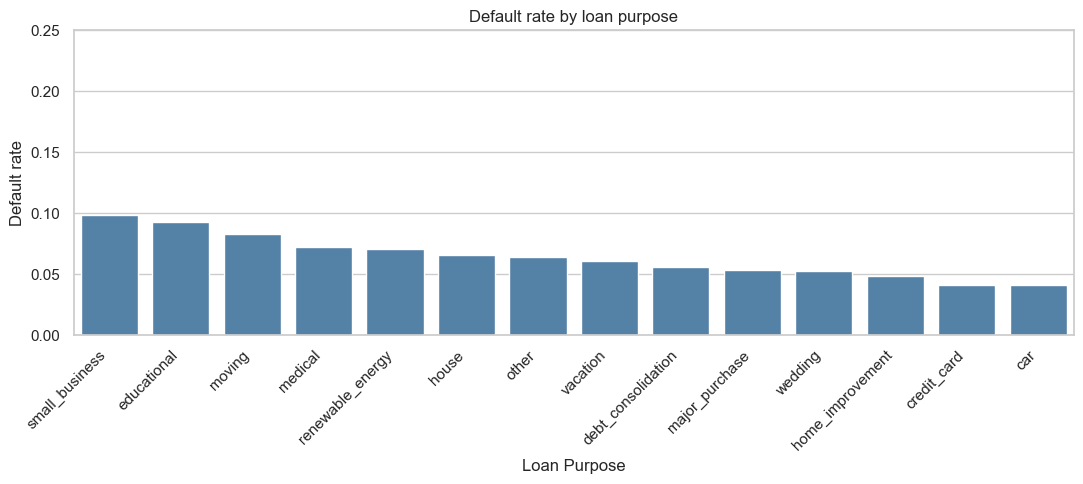

In [20]:
# Does default rate vary with purpose of the loan?
# Default rate by loan purpose, sorted high -> low
purpose_stats = (
    df.groupby('purpose')['target']
      .agg(default_rate='mean', loan_count='count')
      .sort_values('default_rate', ascending=False)
)

plt.figure(figsize=(11, 5))
sns.barplot(x=purpose_stats.index, y=purpose_stats['default_rate'], color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title('Default rate by loan purpose')
plt.ylabel('Default rate')
plt.xlabel('Loan Purpose')
plt.tight_layout()
plt.ylim(0, 0.25)
plt.show()

**Key Observations:**
- **Small business loans** show the **highest default rate** 
- After small business loans, education, moving and medical loans form the next group of high-default purposes. 
- These loan purpose categories could be useful predictors of whether or not a borrower will default on his/her loan.

#### **2.2.3.3 By term**

 - Term: The number of payments on the loan. Values are in months and can be either 36 or 60, which is the contractual loan term chosen at origination. 
 - The default-rate gap between them therefore reflects borrower self-selection (riskier borrowers tend to take longer terms), not differences in how long each group has been observed.
- NOTE: All loans here are evaluated on the same 12-month performance window (the post-filter dataset).



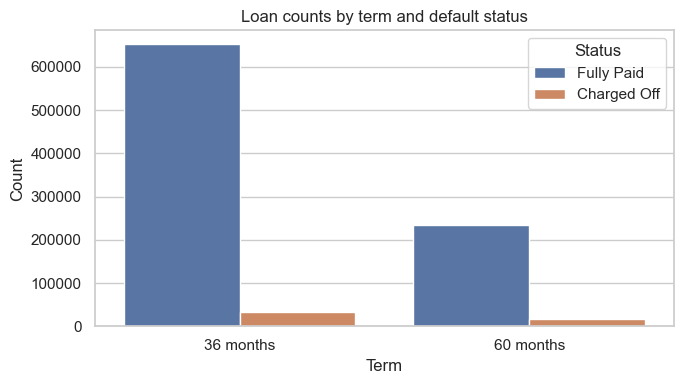

In [21]:
plt.figure(figsize=(7, 4))
sns.countplot(
    data=df,
    x='term',
    hue='target',
    hue_order=[0, 1]
)

plt.title('Loan counts by term and default status')
plt.xlabel('Term')
plt.ylabel('Count')
plt.legend(title='Status', labels=['Fully Paid', 'Charged Off'])
plt.tight_layout()
plt.show()

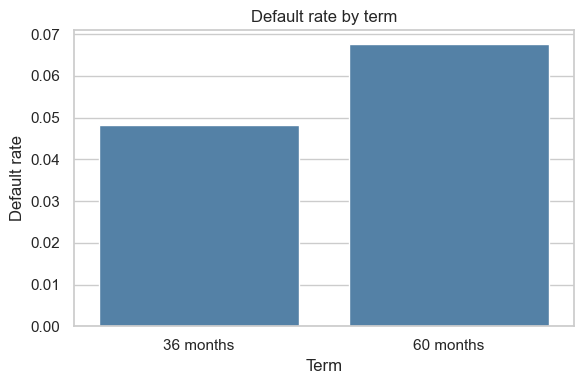

In [22]:
term_default = df.groupby('term')['target'].mean()

plt.figure(figsize=(6, 4))
sns.barplot(
    x=term_default.index,
    y=term_default.values,
    color = 'steelblue'
)

plt.title('Default rate by term')
plt.xlabel('Term')
plt.ylabel('Default rate')
plt.tight_layout()
plt.show()

**Key observations**
- 36-month loans dominate (about 73% of all loans).
- The default rate on 60-month loans is meaningfully higher (about 7% vs 5%, roughly 40% higher).
- This gap is driven by borrower self-selection: riskier borrowers tend to choose longer terms for lower monthly payments.
- It is not about observation time: every loan is judged on the same 12-month window, so both terms are observed for exactly 12 months.
- Term is kept as a feature. Its overlap with DTI and income is conceptual (the same self-selection effect) rather than a strong numerical correlation, so it adds useful signal and stays.



### **2.2.4 Default rate by borrower attributes**

#### **2.2.4.1 By Debt-to-income ratio**
- measures how much of a borrower's monthly income is already committed to existing debt payments, excluding mortgage. 

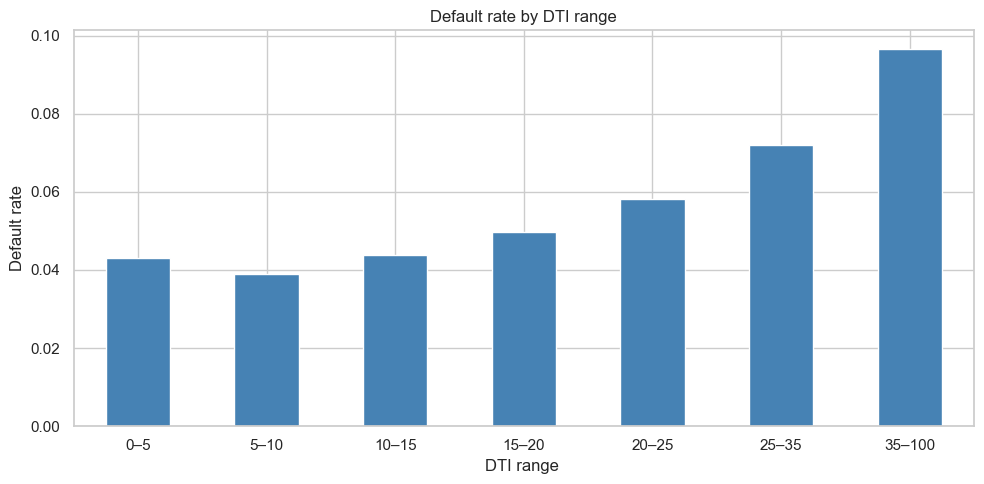

In [23]:
# Create DTI bins 
# DTI bins 
dti_bins = [0, 5, 10, 15, 20, 25, 35, 100]
dti_labels = [f'{dti_bins[i]}–{dti_bins[i+1]}' for i in range(len(dti_bins) - 1)]

# Remove invalid negative DTI values
df_dti = df[df['dti'] >= 0].copy()
df_dti['dti_bin'] = pd.cut(df_dti['dti'], bins=dti_bins, labels=dti_labels)

dti_default = df_dti.groupby('dti_bin')['target'].mean()

dti_default.plot(kind='bar', color='steelblue', figsize=(10, 5))
plt.title('Default rate by DTI range')
plt.xlabel('DTI range ')
plt.ylabel('Default rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [24]:
# Investigate the DTI bin: how many loans are there?
dti_counts = df_dti.groupby('dti_bin').size()
print(dti_counts)

dti_bin
0–5        44870
5–10      123924
10–15     193371
15–20     205171
20–25     170700
25–35     179307
35–100     17744
dtype: int64


**Key observations**

- Default rate stays roughly flat across low-to-mid DTI, then climbs steadily once DTI passes about 20, reaching its highest in the 35-100 band. Borrowers already stretched by existing debt are more likely to miss payments.
- The acceleration above DTI ~20 hints at a financial-stress threshold, a candidate for a simple "high DTI" flag in feature engineering.
- Include this feature: a genuine application-time borrower attribute with a clear risk gradient, and its non-linear (flat-then-rising) shape is exactly what tree models like XGBoost capture well. 
- DTI is a clear predictor of default. The rate stays roughly flat (around 4%) across the low-to-mid range (0 to 15), then climbs steadily to about 10% in the highest bin (35 to 100), roughly a 2.5x spread.

#### **2.2.4.2 By annual income**

In [25]:
# Income distribution - check skewness first for deciding the bins
print(f"Annual income skewness: {df['annual_inc'].skew():.2f}")
print(f"Annual income kurtosis: {df['annual_inc'].kurtosis():.2f}")
print(f"99th percentile: ${df['annual_inc'].quantile(0.99):,.0f}")
print(f"Max value:       ${df['annual_inc'].max():,.0f}")

Annual income skewness: 41.43
Annual income kurtosis: 4151.71
99th percentile: $252,000
Max value:       $9,573,072


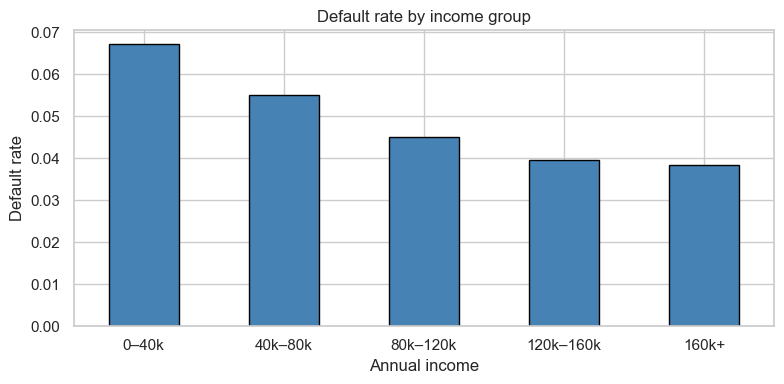

In [26]:
# Bin income
income_bins = [0, 40000, 80000, 120000, 160000, np.inf]
income_labels = ['0–40k', '40k–80k', '80k–120k', '120k–160k', '160k+']

df['income_bin'] = pd.cut(df['annual_inc'], bins=income_bins, labels=income_labels)
income_default = df.groupby('income_bin')['target'].mean()

income_default.plot(kind='bar', color='steelblue', edgecolor='black', figsize=(8, 4))
plt.title('Default rate by income group')
plt.xlabel('Annual income')
plt.ylabel('Default rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Key observations**

- Most borrowers earn modest incomes (nearly all under about $250k), while a few report extremely high figures (up to ~$9.5M) that stretch the data far to the right.
- Default rate falls steadily as income rises, sharply across the lower bands then flattening above about 120k. Lower-income borrowers have less cushion to absorb a financial shock.
- **Include this feature:** a genuine application-time borrower attribute with a clear, downward risk gradient. XGBoost handles the skew and outliers directly, so no transformation is needed.


### **2.2.5 Missingness analysis**

In [27]:
# Missingness per column, sorted
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
})

# Show only columns with at least one missing value
missing_summary[missing_summary['missing_count'] > 0]

,missing_count,missing_pct
dti_joint,927012,99.06
annual_inc_joint,927010,99.06
verification_status_joint,927010,99.06
desc,809795,86.54
mths_since_last_record,784301,83.81
mths_since_last_major_derog,701118,74.92
il_util,558801,59.71
mths_since_rcnt_il,513150,54.84
all_util,501476,53.59
total_cu_tl,501454,53.59


### **2.2.6 Feature scope (leakage audit): which columns to keep or drop**

Before the treatment plan, every column is assigned to an explicit DROP or KEEP bucket. This is the auditable record of the leakage audit: post-origination fields, identifiers, >99%-missing joint fields, the newer ~60%-missing bureau metrics, high-cardinality text, and near-constant columns are dropped; the rest are kept (with a documented missing-value treatment).

In [28]:
# Column categorisation for the leakage audit + feature scope.
# Every column is explicitly assigned to a DROP bucket so the decision is
# auditable. XGBoost handles NaN natively, so no imputation buckets are needed

# --- DROP buckets ---
drop_post_origination = [   # populated only AFTER the loan outcome -> target leakage
    "out_prncp", "out_prncp_inv",
    "total_pymnt", "total_pymnt_inv",
    "total_rec_prncp", "total_rec_int", "total_rec_late_fee",
    "recoveries", "collection_recovery_fee",
    "last_pymnt_d", "last_pymnt_amnt", "next_pymnt_d", "last_credit_pull_d",
]
drop_identifiers = [        # unique IDs - no predictive value
    "id", "member_id",
]
drop_joint = [              # joint-application fields, >99% missing
    "annual_inc_joint", "dti_joint", "verification_status_joint",
]
drop_newer_bureau = [       # bureau metrics added in later LC releases, ~60% missing
    "open_acc_6m", "open_il_12m", "open_il_24m", "mths_since_rcnt_il",
    "total_bal_il", "il_util", "open_rv_12m", "open_rv_24m",
    "max_bal_bc", "all_util", "inq_fi", "total_cu_tl", "inq_last_12m",
]
drop_text = [               # high-cardinality / free-text - need NLP, out of scope
    "emp_title", "desc", "title", "zip_code",
]
drop_constant = [           # near-constant, no variance to learn from
    "policy_code", "pymnt_plan",
]
drop_lc_risk_output = [     # LC's own risk decision + pricing -> circular as features
    "grade", "sub_grade", "int_rate",
]
drop_correlated = [         # near-duplicate of another kept feature
    "funded_amnt",             # = loan_amnt (1.00)
    "installment",             # ≈ loan_amnt (0.97), mechanically derived
    "mths_since_last_record",  # ≈ -pub_rec (-0.98)
]
drop_other = [              # target source/helpers, split-key tags, EDA helpers
    "loan_status", "funded_amnt_inv", "income_bin",
    "months_to_last_pymnt", "months_observed", "_source",
]

# Split keys: kept in df for the time-based split, but NOT model features.
split_keys = ['issue_d', 'issue_year']

# usable_features = everything not dropped, not a split key, and not the target.
_all_drops = (drop_post_origination + drop_identifiers + drop_joint
              + drop_newer_bureau + drop_text + drop_constant
              + drop_lc_risk_output + drop_correlated + drop_other)
usable_features = [c for c in df.columns
                   if c not in _all_drops and c not in split_keys and c != 'target']

print(f"Columns flagged to DROP : {len(_all_drops)}")
print(f"Usable features (KEEP)  : {len(usable_features)}")

Columns flagged to DROP : 49
Usable features (KEEP)  : 26


In [29]:
# Treatment plan based on the audit, which is a reference for Data Cleaning part.
# XGBoost handles NaN natively, so kept features need no imputation.
treatment_plan = pd.DataFrame([
    {'Action': 'DROP', 'Reason': 'Post-origination (leakage)',         'Count': len(drop_post_origination)},
    {'Action': 'DROP', 'Reason': 'Identifiers',                         'Count': len(drop_identifiers)},
    {'Action': 'DROP', 'Reason': 'Joint fields (>99% missing)',         'Count': len(drop_joint)},
    {'Action': 'DROP', 'Reason': 'Newer bureau metrics (~60% missing)', 'Count': len(drop_newer_bureau)},
    {'Action': 'DROP', 'Reason': 'High-cardinality text',               'Count': len(drop_text)},
    {'Action': 'DROP', 'Reason': 'Near-constant',                       'Count': len(drop_constant)},
    {'Action': 'DROP', 'Reason': 'LC risk output (circular)',           'Count': len(drop_lc_risk_output)},
    {'Action': 'DROP', 'Reason': 'Correlated duplicates',               'Count': len(drop_correlated)},
    {'Action': 'DROP', 'Reason': 'Helpers / used elsewhere',            'Count': len(drop_other)},
    {'Action': 'KEEP', 'Reason': 'Usable feature (NaN handled by XGBoost)', 'Count': len(usable_features)},
])

print(f"Total usable features for modelling: {len(usable_features)}")
treatment_plan

Total usable features for modelling: 26


,Action,Reason,Count
0,DROP,Post-origination (leakage),13
1,DROP,Identifiers,2
2,DROP,Joint fields (>99% missing),3
3,DROP,Newer bureau metrics (~60% missing),13
4,DROP,High-cardinality text,4
5,DROP,Near-constant,2
6,DROP,LC risk output (circular),3
7,DROP,Correlated duplicates,3
8,DROP,Helpers / used elsewhere,6
9,KEEP,Usable feature (NaN handled by XGBoost),26


### **2.2.7 Distributions and correlation of kept features**

In [30]:
# Identify usable numeric features:
usable_numeric = [c for c in usable_features if df[c].dtype in ['int64', 'int32', 'float64', 'float32']]
print(f"Usable numeric features: {len(usable_numeric)}")

Usable numeric features: 17


In [31]:
# Some numeric features aren't informative as histograms
exclude_from_viz = [
    'acc_now_delinq',
    'collections_12_mths_ex_med',
    'mths_since_last_delinq',
    'mths_since_last_major_derog',
    'mths_since_last_record',
]

numeric_features = [c for c in usable_numeric if c not in exclude_from_viz]
print(f"Visualising {len(numeric_features)} features (excluding mostly-zero and high-missing)")

Visualising 13 features (excluding mostly-zero and high-missing)


**NOTE:** Some features have extreme outliers or heavy right-skew that make raw histograms unreadable but XGBoost is scale-invariant, so no transform is applied at modelling time. The log scale here is only for the chart, to make the long tail readable.

Two types of transformations are applied for readability purpose:

**1. LOG SCALE:** This is for heavily right-skewed to compress the long tail and reveals the actual distribution shape. Features that apply log scale are `annual_inc`, 
`revol_bal`, `tot_cur_bal`, `total_rev_hi_lim`

**2. CLIP:** This is for features where extreme values are likely data errors rather than legitimate outliers. DTI above 100% is implausible for a healthy applicant, so those rows are excluded from the visualisation


Visualising 9 features (excluding zero-inflated, high-missing, and time-key columns)


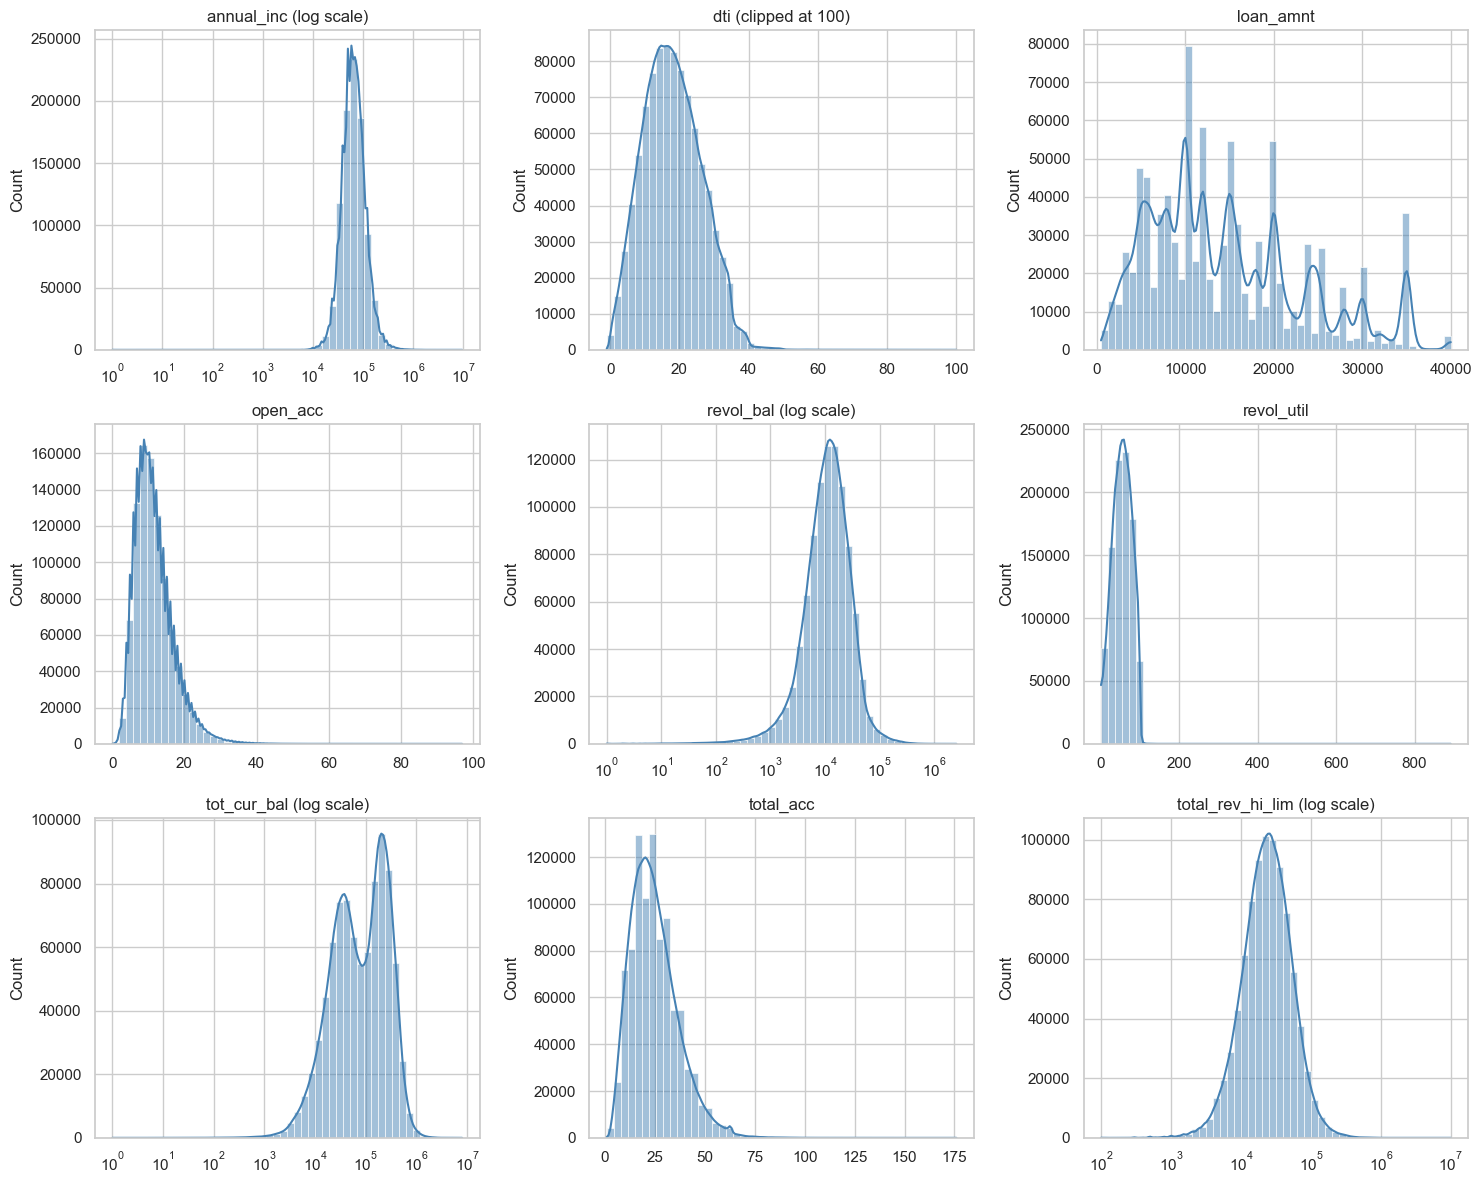

In [32]:
# Numeric columns that aren't informative as histograms:
#  - zero-inflated counts/amounts (a single spike at 0 dominates the chart)
#  - high-missing "months since" fields
#  - issue_year (a time key used for the split, not a borrower feature)
exclude_from_viz = [
    'acc_now_delinq', 'collections_12_mths_ex_med',
    'delinq_2yrs', 'inq_last_6mths', 'pub_rec', 'tot_coll_amt',
    'mths_since_last_delinq', 'mths_since_last_major_derog', 'mths_since_last_record',
    'issue_year',
]
numeric_features = [c for c in usable_numeric if c not in exclude_from_viz]
print(f"Visualising {len(numeric_features)} features "
      f"(excluding zero-inflated, high-missing, and time-key columns)")

# Transformations
# log scale: heavily right-skewed continuous money features
log_scale_features = [
    'annual_inc',         # income from $4k to $9.5M
    'revol_bal',          # revolving balance, mostly $1k-$30k with long tail
    'tot_cur_bal',        # total current balance across all accounts
    'total_rev_hi_lim',   # total revolving credit limit
]
# clip: extreme values are likely data errors, not real
clip_features = {
    'dti': 100,           # DTI above 100% is unrealistic for healthy borrowers
}

# Grid setup
n_features = len(numeric_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

# Plot each feature with the appropriate transformation
for i, col in enumerate(numeric_features):
    data = df[col].dropna()

    if col in log_scale_features:
        data = data[data > 0]                       # log needs strictly positive values
        sns.histplot(data, bins=50, ax=axes[i], color='steelblue', kde=True, log_scale=True)
        axes[i].set_title(f"{col} (log scale)")
    elif col in clip_features:
        data = data[data <= clip_features[col]]
        sns.histplot(data, bins=50, ax=axes[i], color='steelblue', kde=True)
        axes[i].set_title(f"{col} (clipped at {clip_features[col]})")
    else:
        sns.histplot(data, bins=50, ax=axes[i], color='steelblue', kde=True)
        axes[i].set_title(col)

    axes[i].set_xlabel('')

# Hide unused subplots
for j in range(n_features, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


**Key observations**

- `loan_amnt' clusters at round numbers. The comb-like spikes at $5k, $10k, $15k and so on show borrowers request round figures, not precise amounts. This is borrower behaviour, not a data error, so nothing needs cleaning; it just means the feature is lumpy, which tree splits handle without issue.

- 'tot_cur_bal' is bimodal. Two clear groups appear: a small cluster with very low total balances and a larger group at high balances. The low group likely reflects thin-file borrowers with little credit history. This is a real population split, not an artifact, and it is useful signal, since XGBoost can isolate the thin-file group directly.

- 'revol_util' runs past 100%. Utilisation should cap at 100%, but the tail extends well beyond it, a small set of implausible values. This is a data-quality flag. It is left in rather than filtered, since XGBoost treats extreme values as their own region, but it is worth noting as a limitation.

- The remaining features (`dti` clipped, `open_acc`, `total_acc`) are roughly bell-shaped or moderately right-skewed. Nothing else flagged for cleaning.


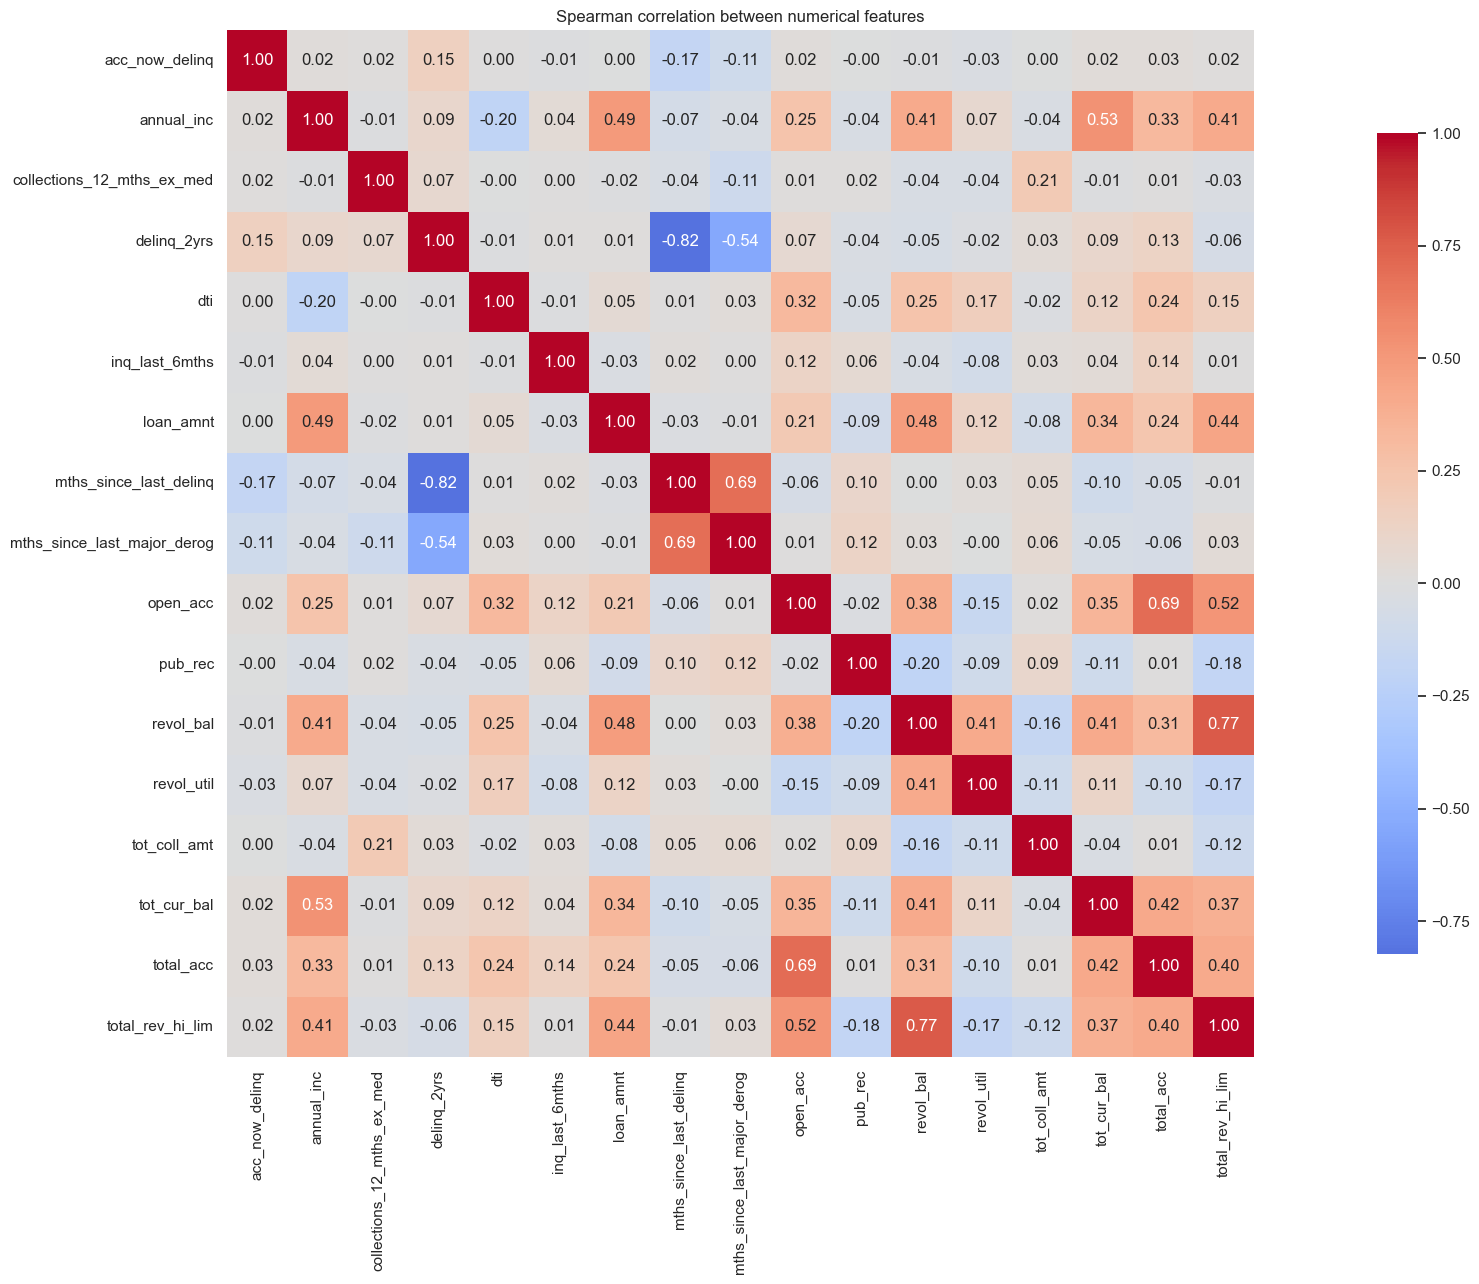

In [33]:
# Correlation heatmap (Spearman is selected because robust to outliers in skewed financial data)
corr = df[usable_numeric].corr(method='spearman')   # use the full numeric feature set, not the trimmed histogram set

plt.figure(figsize=(25, 13))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Spearman correlation between numerical features')
plt.tight_layout()
plt.show()

**Key correlations after the redundancy drops:**

- The strongest remaining pair is `delinq_2yrs` and `mths_since_last_delinq` (−0.82): a borrower with more recent delinquencies naturally has fewer months since the last one, so it is two views of the same credit history.
- Other notable pairs are conceptually distinct and each still adds information: `revol_bal` / `total_rev_hi_lim` (0.77) (balance used vs limit available), `open_acc` / `total_acc` (0.69) (current vs all-time accounts), and `mths_since_last_delinq` / `mths_since_last_major_derog` (0.69) (two related credit-event timers).

- Handling: nothing is dropped. XGBoost is tree-based, so it is robust to multicollinearity, unlike logistic regression where correlated inputs destabilise the coefficients and one of a pair would usually be dropped. None of these reach the near-duplicate level (around 0.95+) that already removed `funded_amnt`, `installment`, and `mths_since_last_record`, and each pair carries a distinct angle, so all are kept.
- One caveat for interpretation: correlated features can split their importance between each other, so the SHAP ranking for these pairs should be read as a shared contribution rather than fully independent ones.


## **3. Data Preparation**


### **3.1 Data cleaning**

**Note on annual_inc outliers:** During EDA extreme values are identified
in `annual_inc` (max $9.5M, 99th percentile $250k). However, these values are chosen not to cap 
or filter during cleaning because:

- XGBoost (primary model) handles outliers robustly without preprocessing
- For the logistic regression baseline, log-transformation of `annual_inc` 
  in Feature Engineering part naturally compresses the long tail


In [34]:
# Capture the pre-cleaning default rate as a reference for the impact of the cleaning steps. This is a key metric to
default_rate_before_cleaning = df['target'].mean()
print(f"Default rate before cleaning: {default_rate_before_cleaning:.2%}")

Default rate before cleaning: 5.34%


### **3.1.1 Drop columns flagged in EDA (2.2.6)**

In [35]:
# Compile all columns to drop, based on EDA categorisation
# (These lists were defined in Section 2.2.5)

columns_to_drop = (
    drop_post_origination +     # would leak the target
    drop_identifiers +          # not features
    drop_joint +                # >99% missing
    drop_newer_bureau +         # ~60% missing
    drop_text +                 # high-cardinality text
    drop_constant +             # near-constant
    drop_lc_risk_output +       # grade, sub_grade, int_rate -> LC's own decision (circular)
    drop_correlated +           # funded_amnt, installment, mths_since_last_record -> near-duplicates
    drop_other                  # target source, split keys, EDA helpers
)
# Defensive filter to keep only columns actually present
columns_to_drop = [c for c in columns_to_drop if c in df.columns]

# Record the dataset state before dropping variables to make sure nothing unexpected happens.
shape_before = df.shape

# Apply the drop
df = df.drop(columns=columns_to_drop)

print(f"Shape before drop: {shape_before}")
print(f"Shape after drop:  {df.shape}")
print(f"Dropped {len(columns_to_drop)} columns; {df.shape[1]} columns remain.")

Shape before drop: (935799, 78)
Shape after drop:  (935799, 29)
Dropped 49 columns; 29 columns remain.


### **3.1.2 Handle missing values**

**Skipped — XGBoost handles missing values natively** 
- It learns a default split direction for missing values, so no imputation is applied. Leaving them as NaN avoids inventing values and lets the model use "missingness" itself as signal. Remaining missing counts are shown in the 3.1.4 summary.

### **3.1.3 Filter implausible values**

EDA identified a small number of rows with DTI values above 100%, which is implausible for a healthy applicant and almost certainly data errors. These rows are removed.

In [36]:
# Filter DTI outliers (>100% is implausible for healthy borrowers)
rows_before = len(df)
df = df[df['dti'] <= 100].copy()
rows_after = len(df)

print(f"Rows before DTI filter: {rows_before:,}")
print(f"Rows after DTI filter:  {rows_after:,}")
print(f"Removed: {rows_before - rows_after:,} ({(rows_before - rows_after) / rows_before:.2%})")

Rows before DTI filter: 935,799
Rows after DTI filter:  935,610
Removed: 189 (0.02%)


### **3.1.4 Cleaned dataset summary**

Verify the cleaned dataset is ready for the next stage:
- Reasonable shape (rows and columns)
- Default rate hasn't shifted materially from the EDA stage
- If missing values remain, that's intended because XGBoost handles them natively

In [37]:
# Reset index after row filtering to avoid gaps
df = df.reset_index(drop=True)

print("CLEANED DATASET SUMMARY")
print(f"\nShape: {df.shape[0]:,} rows x {df.shape[1]} columns")

# Class balance of the modelling dataset. Row filtering is complete by this point
# (later feature-engineering steps change columns, not rows), so this is the
# imbalance the model actually faces.
print("\nClass balance (target):")
counts = df['target'].value_counts().sort_index()
labels = {0: 'Non-default (0)', 1: 'Default (1)'}
for cls, n in counts.items():
    print(f"  {labels[cls]:16} {n:>8,}  ->  {n / len(df):6.2%}")
print(f"\n  Imbalance ratio (non-default : default) = {counts[0] / counts[1]:.1f} : 1")

# Sanity check: the DTI row filter should not have shifted the default rate.
print(f"\nDefault rate: {default_rate_before_cleaning:.2%} before cleaning -> "
      f"{df['target'].mean():.2%} after (stable; DTI filter removed few rows).")

# Confirm remaining missingness is expected (XGBoost handles NaN natively)
print("\nRemaining missingness:")
remaining_missing = df.isnull().sum().sort_values(ascending=False)
remaining_missing = remaining_missing[remaining_missing > 0]
if len(remaining_missing) > 0:
    print(remaining_missing)
else:
    print("  No missing values remain.")

CLEANED DATASET SUMMARY

Shape: 935,610 rows x 29 columns

Class balance (target):
  Non-default (0)   885,692  ->  94.66%
  Default (1)        49,918  ->   5.34%

  Imbalance ratio (non-default : default) = 17.7 : 1

Default rate: 5.34% before cleaning -> 5.34% after (stable; DTI filter removed few rows).

Remaining missingness:
mths_since_last_major_derog    700977
mths_since_last_delinq         472107
total_rev_hi_lim                70276
tot_cur_bal                     70276
tot_coll_amt                    70276
emp_length                      50924
revol_util                        614
collections_12_mths_ex_med        145
inq_last_6mths                     30
total_acc                          29
pub_rec                            29
open_acc                           29
acc_now_delinq                     29
earliest_cr_line                   29
delinq_2yrs                        29
annual_inc                          4
dtype: int64


### **3.2 Feature Engineering**

The leakage audit and feature selection were done in EDA (2.2.5). This step converts the columns stored as text into the numeric form XGBoost needs. These conversions are deterministic (they do not use the target), so applying them to the full dataset is leakage-safe.

- `term`: " 36 months" (text data) -> 36 (numeric data)
- `emp_length`: ordinal 0-10, with censored endpoints (0 = under 1 year, 10 = 10 or more years) as in the source data. Only the ordering matters to a tree.
- `earliest_cr_line`: a date, converted to credit_history_months (`issue_d` minus `earliest_cr_line`), then the raw date is dropped. Longer credit history is a meaningful risk signal.
- Nominal categories (`purpose`, `home_ownership`, and so on) are one-hot encoded in the next cell. The one exception is the high-cardinality `addr_state`, target-encoded inside the 4. pipeline so it is fit on training data only.

### **3.2.1 Numeric conversions**
- term / emp_length / credit_history_months

In [38]:
# Convert string-encoded numerics to numeric form. These transforms are
# deterministic (they do not use the target), so applying them to the full
# dataset is leakage-safe.

# term: " 36 months" -> 36 (extract the month count)
df['term'] = df['term'].str.extract(r'(\d+)', expand=False).astype('int')

# emp_length: ordinal 0-10, with censored endpoints
# ("< 1 year" -> 0, "10+ years" -> 10). NaNs are left as missing for XGBoost.
emp_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
    '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9,
    '10+ years': 10,
}
df['emp_length'] = df['emp_length'].map(emp_map).astype('float64')

# earliest_cr_line: date -> months of credit history at origination, then drop
# the raw date. Longer credit history is a meaningful risk signal.
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y', errors='coerce')
df['credit_history_months'] = (
    (df['issue_d'].dt.year  - df['earliest_cr_line'].dt.year) * 12
    + (df['issue_d'].dt.month - df['earliest_cr_line'].dt.month)
)
df = df.drop(columns=['earliest_cr_line'])

# Confirm the three are now numeric
print(df[['term', 'emp_length', 'credit_history_months']].dtypes)
print()
print(df[['term', 'emp_length', 'credit_history_months']].describe())

term                       int64
emp_length               float64
credit_history_months    float64
dtype: object

                term     emp_length  credit_history_months
count  935610.000000  884686.000000          935581.000000
mean       42.429756       6.023685             195.680121
std        10.628852       3.668581              90.137615
min        36.000000       0.000000               6.000000
25%        36.000000       3.000000             135.000000
50%        36.000000       6.000000             178.000000
75%        60.000000      10.000000             241.000000
max        60.000000      10.000000             999.000000


### **3.2.2 Categorical variables and dummy variables**

Nominal categorical columns are converted to numeric form for XGBoost. These transforms do not use the target, so they are leakage-safe on the full dataset. High-cardinality addr_state is the exception, target-encoded in the 4 pipeline (fit on training data only).

- `application_type`: `is_joint`: the two files recorded it differently (INDIVIDUAL vs Individual, JOINT vs Joint App), which the 2.1.5 whitespace strip missed. Values are standardised, then reduced to a binary flag (1 = joint, 0 = individual). Joint is ~2% of loans, so one flag is enough.
- `home_ownership`, `verification_status`, `purpose`, `initial_list_status`: one-hot encoded (2 to 14 categories each, so the column count stays manageable). Tree models do not need a reference category dropped.
- `term` stays numeric (36/60): with two values it is already equivalent to a dummy for a tree.

In [39]:
# --- application_type: fix cross-file casing, then reduce to a binary flag -----
# The two files used different forms (INDIVIDUAL/Individual, JOINT/Joint App);
# the §2.1.5 strip only removed whitespace, so the case mismatch survived.
df['application_type'] = df['application_type'].str.strip().str.lower()
df['is_joint'] = df['application_type'].isin(['joint app', 'joint']).astype('int')
df = df.drop(columns=['application_type'])

# --- one-hot (dummy) encode the low-cardinality nominal categoricals ----------
dummy_cols = ['home_ownership', 'verification_status', 'purpose', 'initial_list_status']
df = pd.get_dummies(df, columns=dummy_cols, dummy_na=False, dtype='int')

print("is_joint distribution:")
print(df['is_joint'].value_counts())
print(f"\nColumns after dummy encoding: {df.shape[1]}")
print("Sample new dummy columns:",
      [c for c in df.columns if c.startswith(('home_ownership_', 'purpose_'))][:6])

is_joint distribution:
is_joint
0    927010
1      8600
Name: count, dtype: int64

Columns after dummy encoding: 50
Sample new dummy columns: ['home_ownership_ANY', 'home_ownership_MORTGAGE', 'home_ownership_NONE', 'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT']


### **3.2.3 Final feature set**

All column transformations are complete, so the modelling feature set is fixed here and reused for every split and model. `issue_d` and `issue_year` stay in `df` for building the time-based split but are not features; `target` is the label.

In [40]:
# Feature set is now final. Defined once here and reused for every split and model.
non_features = ['target', 'issue_d', 'issue_year']
feature_cols = [c for c in df.columns if c not in non_features]

print(f"Final modelling feature set: {len(feature_cols)} features")
remaining_cat = [c for c in feature_cols if not pd.api.types.is_numeric_dtype(df[c])]
print(f"Still-categorical (left for the Section 4 pipeline): {remaining_cat}")
print(f"{remaining_cat}")

Final modelling feature set: 47 features
Still-categorical (left for the Section 4 pipeline): ['addr_state']
['addr_state']


### **3.3 Data split**

### **3.3.1 Build the model matrix X, Y**

- `X` holds the final feature set from 3.2.3 
- `Y` is the 12-month default label. 
- NOTE: `addr_state` is still text here and gets target-encoded later inside the 4 pipeline, so it stays in X for now.

In [42]:
X = df[feature_cols]
y = df['target']
print(f"X: {X.shape[0]:,} rows x {X.shape[1]} features    |    y default rate: {y.mean():.2%}")


X: 935,610 rows x 47 features    |    y default rate: 5.34%


### **3.3.2: Random Split (stratified 80/20)**

- **What it is**: 80% of loans go to training and 20% to testing, picked at random from across all years.
- **Why "optimistic**"**: both sides hold a similar mix of borrowers from the same periods, so it measures how the model does on customers similar to those it trained on. It does not test how it copes with newer loans, which is the out-of-time split's job.
- **Stratified on the target**: both sides keep the same ~5.3% default rate. Defaults are rare, so a plain random split could, by chance, put too few (or too many) defaults on one side. Stratifying prevents that, so the test set reflects the true default rate.
- `random_state` **fixed**: the same split is produced every run, so the results are reproducible.


In [43]:
from sklearn.model_selection import train_test_split

X_train_rand, X_test_rand, y_train_rand, y_test_rand = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print("Random split (80/20, stratified):")
print(f"  train: {len(X_train_rand):>7,} rows  |  default rate {y_train_rand.mean():.2%}")
print(f"  test:  {len(X_test_rand):>7,} rows  |  default rate {y_test_rand.mean():.2%}")


Random split (80/20, stratified):
  train: 748,488 rows  |  default rate 5.34%
  test:  187,122 rows  |  default rate 5.34%


### **3.3.3: Out-of-time split (train on earlier years and test on the later years)**

- **What it is**: train on loans issued up to 2015, test on loans issued in 2016.
- **Why "deployment-realistic"**: this mimics real use, where a model trained on past loans scores new loans issued later. It shows how the model holds up once the borrower mix and economy have moved on.
- **The boundary**: the 2015/2016 cut follows the two source files (`lc_loan` file ends in 2015, `lc_2016_2017` file supplies 2016), and 2016 has a full 12-month window, so its outcomes are complete.
- **Deliberately not stratified**: unlike the random split, each side keeps its own natural default rate. The gap between train and 2016 test then reveals real drift over time, which is exactly what this split exists to measure.

In [45]:
# Train on loans issued up to 2015; test on the 2016 vintage.
oot_train_mask = df['issue_year'] < 2016
oot_test_mask  = df['issue_year'] == 2016

X_train_oot, y_train_oot = X[oot_train_mask], y[oot_train_mask]
X_test_oot,  y_test_oot  = X[oot_test_mask],  y[oot_test_mask]

yr = df['issue_year']
print("Out-of-time split:")
print(f"  train ({yr[oot_train_mask].min()}-{yr[oot_train_mask].max()}): "
      f"{len(X_train_oot):>7,} rows  |  default rate {y_train_oot.mean():.2%}")
print(f"  test  (2016):      {len(X_test_oot):>7,} rows  |  default rate {y_test_oot.mean():.2%}")


Out-of-time split:
  train (2007-2015): 501,392 rows  |  default rate 4.71%
  test  (2016):      434,218 rows  |  default rate 6.06%


### **3.3.4: Verify both splits**

- **Sanity check**: the random split should show near-identical default rates on both sides (stratification working); the OOT split may show a gap between train and 2016 test, which is the real-world drift this split is meant to reveal.

In [46]:
split_summary = pd.DataFrame([
    {'split': 'random', 'part': 'train', 'rows': len(X_train_rand), 'default_rate_%': round(y_train_rand.mean()*100, 2)},
    {'split': 'random', 'part': 'test',  'rows': len(X_test_rand),  'default_rate_%': round(y_test_rand.mean()*100, 2)},
    {'split': 'oot',    'part': 'train', 'rows': len(X_train_oot),  'default_rate_%': round(y_train_oot.mean()*100, 2)},
    {'split': 'oot',    'part': 'test',  'rows': len(X_test_oot),   'default_rate_%': round(y_test_oot.mean()*100, 2)},
])
split_summary


,split,part,rows,default_rate_%
0,random,train,748488,5.34
1,random,test,187122,5.34
2,oot,train,501392,4.71
3,oot,test,434218,6.06


- Random split: train and test are both identical, which is exactly 5.34%. 
- OOT split: train 4.71% vs 2016 test 6.06%, a real upward drift in default rate. This is exactly the deployment signal the OOT split exists to expose: 2016 loans defaulted more than the earlier vintages the model trains on. 

## **4. Modelling**

### **4.1 Untuned XGBoost (Baseline)**

### **4.1.1: Imports library**

In [47]:
from sklearn.preprocessing import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.metrics import roc_auc_score, average_precision_score
from xgboost import XGBClassifier


### **4.1.2 Preprocessing: target-encode addr_state**
- **Why:** Everything else is already numeric (dummies, flags, numbers). TargetEncoder lives inside the pipeline, so it's fit on the training data only and the test set never contributes to the encoding.


In [48]:
preprocess = ColumnTransformer(
    transformers=[('addr', TargetEncoder(target_type='binary'), ['addr_state'])],
    remainder='passthrough',   # all other columns pass straight through
)


### **4.1.3: Build the baseline model and pipeline**

- **This is a build step, not a result.** It defines the untuned model: XGBoost with default hyperparameters, no tuning, no `scale_pos_weight`. No numbers are produced here.
- **The reference comes in 4.1.5.** The model is fit and scored there, and those scores become the baseline the tuned model must beat.
- **Why untuned:** keeping it plain means any later improvement is clearly attributable to tuning, not to other changes.
- **The pipeline** chains the `addr_state` encoder with the model, so the encoder is fit on training data only (no leakage).


In [49]:
# Create a baseline model
baseline_xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    tree_method='hist',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
# Chain preprocessing and model into one object so the encoder is fit on training data only (no leakage).
baseline_pipe = Pipeline([('pre', preprocess), ('clf', baseline_xgb)])


### **4.1.4 Train-and-score helper**

- **What this does:** defines a small function that takes a split (training set + test set), trains the pipeline on the training set, then returns its performance on the held-out test set (AUC, PR-AUC, Gini).

- **Why it is needed:** the same train-then-score routine runs several times in this notebook (random split, out-of-time split, and later the tuned model). Writing it once as a function keeps every evaluation identical, avoids copy-paste mistakes, and enforces the rule that the model is fit only on training data and scored only once on the test set.

In [48]:
def fit_and_score(pipe, X_tr, y_tr, X_te, y_te, label):
    """Fit a fresh copy of `pipe` on the training split, score AUC / PR-AUC / Gini
    on the held-out test split. The pipeline (encoder + model) sees only training
    data, so the test set stays untouched. Returns a metrics dict for the summary.
    """
    model = clone(pipe)
    model.fit(X_tr, y_tr)
    p = model.predict_proba(X_te)[:, 1]          # probability of default
    auc = roc_auc_score(y_te, p)
    return {
        'split':  label,
        'AUC':    auc,
        'PR_AUC': average_precision_score(y_te, p),
        'Gini':   2 * auc - 1,                    # standard credit-scoring metric
    }


### **4.1.5 Untuned results: random vs out-of-time** 

- **What this does:** runs the train-and-evaluate helper on both splits (random and out-of-time) and collects the scores into one table.

- **Why both splits:** this comparison is the headline result. The random split shows performance on same-era borrowers; the out-of-time split shows performance on later loans, which is what a deployed model actually faces. The gap between them measures how much the model relies on the future resembling the past.

- **Why these metrics:** AUC and Gini measure how well risk is rank-ordered, but with only 5.3% defaults AUC can look flattering. PR-AUC focuses on the rare default class, giving a more honest read under imbalance.

In [49]:
baseline_results = pd.DataFrame([
    fit_and_score(baseline_pipe, X_train_rand, y_train_rand, X_test_rand, y_test_rand, 'random'),
    fit_and_score(baseline_pipe, X_train_oot,  y_train_oot,  X_test_oot,  y_test_oot,  'oot'),
]).round(4)
baseline_results


,split,AUC,PR_AUC,Gini
0,random,0.6612,0.0969,0.3225
1,oot,0.6431,0.0996,0.2862


### **4.1.6 Interpretation of untuned results:**

- **The model does slightly worse on newer loans.** It scores 0.66 (AUC) on the random split but 0.64 on the 2016 test set. In other words, loans from a later year are a bit harder to predict than loans from the same time the model learned from. This 0.64 is the number that matters most: when tuning later, the aim is to beat this, not the easier random score.

- **Do not compare PR-AUC between the two splits.** The 2016 test set simply has more defaults in it, and PR-AUC naturally looks higher when there are more defaults to find. That is why 2016's PR-AUC is a little higher even though the model is actually doing slightly worse there. So only read PR-AUC within one split, not across the two.

### **4.2 Hyperparameter tuning with Optuna**

### **4.2.1 Import the tuning tools**

In [ ]:
# Import Optuna and cross-validation tools for the upcoming hyperparameter tuning step. Optuna is a powerful and flexible library for hyperparameter optimization, and cross-validation will help us get a more robust estimate of model performance during tuning.
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score


### **4.2.2 Define the objective function**

- **What this does:** defines the function Optuna calls on every trial. Each trial proposes one set of XGBoost hyperparameters (within the ranges given), scores that model with 5-fold StratifiedKFold cross-validation on the training set, and returns the average AUC. Optuna uses that score to choose which combination to try next.

- **Why cross-validation inside:** grading a combination on a single split would be noisy. Five folds average over five train/validation rotations for a stabler estimate, and StratifiedKFold keeps the ~5.3% default rate in every fold.

- **Why the pipeline inside the CV:** cross_val_score refits the whole pipeline (encoder + model) on each fold, so addr_state is target-encoded using only that fold's training portion. That keeps the encoding leakage-free. This is the inner loop of the nested evaluation; the outer test set is never touched here.

In [ ]:
def objective(trial, X_tr, y_tr):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 200, 1000),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma':            trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-3, 5.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1.0, 10.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 20.0),  # to handle the imbalance non-default:default (17.7:1) data
    }
    model = XGBClassifier(objective='binary:logistic', eval_metric='auc',
                          tree_method='hist', random_state=RANDOM_STATE, n_jobs=-1, **params)
    pipe = Pipeline([('pre', preprocess), ('clf', model)])
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    return cross_val_score(pipe, X_tr, y_tr, cv=skf, scoring='roc_auc', n_jobs=1).mean()


### **4.2.3 Define the study runner**

- **What this does:** defines a helper that sets up an Optuna study and runs the search on a given training set. study.optimize calls the objective function n_trials times. Each time trying a new hyperparameter combination and keeping the best one found.

- **Why these settings:**

    - direction = "maximize" because the objective returns AUC, where higher is better.
    - storage = "sqlite:///optuna_study.db" with 
    load_if_exists = True saves the search to a file, so it can be stopped and resumed instead of starting over.
    - Writing it as a function means the same search can run on each split with a single line (4.2.4).

In [52]:
def run_study(X_tr, y_tr, study_name, n_trials=30):
    study = optuna.create_study(
        study_name=study_name,
        storage="sqlite:///optuna_study.db",
        direction="maximize",
        load_if_exists=True,
    )
    study.optimize(lambda t: objective(t, X_tr, y_tr), n_trials=n_trials)
    print(f"[{study_name}] best CV AUC: {study.best_value:.4f}")
    return study


### **4.2.4 Run the search on each split**

- **What this does:** runs the Optuna search twice, once on each outer split's training set (random, then out-of-time). Each call tries n_trials hyperparameter combinations and returns its study holding the best settings found.

- **Why two separate searches:** each outer split is tuned only on its own training set, so the matching test set is never used during tuning. Tuning once and reusing the result would leak, because the random and out-of-time partitions overlap.

- **Note:** unlike 4.2.2 and 4.2.3, this step actually runs the search, so it produces output and takes time (tens of minutes for both). The saved optuna_study.db means it can be stopped and resumed without starting over.



In [ ]:
study_rand = run_study(X_train_rand, y_train_rand, "xgb_random", n_trials=30)
study_oot  = run_study(X_train_oot,  y_train_oot,  "xgb_oot",    n_trials=30)


[I 2026-06-06 15:48:26,767] A new study created in RDB with name: xgb_random
[I 2026-06-06 15:51:41,737] Trial 0 finished with value: 0.6698548404304656 and parameters: {'n_estimators': 511, 'max_depth': 8, 'learning_rate': 0.010810427262173251, 'subsample': 0.7847717693322829, 'colsample_bytree': 0.6138035707223973, 'min_child_weight': 1, 'gamma': 3.551117673254013, 'reg_alpha': 0.7833339503290079, 'reg_lambda': 4.862278656979367, 'scale_pos_weight': 3.040956755092475}. Best is trial 0 with value: 0.6698548404304656.
[I 2026-06-06 15:53:03,498] Trial 1 finished with value: 0.6698139859309298 and parameters: {'n_estimators': 315, 'max_depth': 6, 'learning_rate': 0.03259728968019983, 'subsample': 0.6842715174331301, 'colsample_bytree': 0.8326858338774525, 'min_child_weight': 10, 'gamma': 1.109024263940972, 'reg_alpha': 0.01895044683675587, 'reg_lambda': 5.716123298743211, 'scale_pos_weight': 9.891469063725385}. Best is trial 0 with value: 0.6698548404304656.
[I 2026-06-06 15:53:49,665] 

[xgb_random] best CV AUC: 0.6726


[I 2026-06-06 17:09:29,963] Trial 0 finished with value: 0.6548878697029227 and parameters: {'n_estimators': 551, 'max_depth': 8, 'learning_rate': 0.041532661302120084, 'subsample': 0.6659513389376311, 'colsample_bytree': 0.7659324970395235, 'min_child_weight': 7, 'gamma': 2.9091768618660545, 'reg_alpha': 1.8248937058608632, 'reg_lambda': 2.915166378869427, 'scale_pos_weight': 15.520403187195537}. Best is trial 0 with value: 0.6548878697029227.
[I 2026-06-06 17:09:59,651] Trial 1 finished with value: 0.6606486781019166 and parameters: {'n_estimators': 409, 'max_depth': 5, 'learning_rate': 0.11833903133432215, 'subsample': 0.779496982972339, 'colsample_bytree': 0.8583012935637242, 'min_child_weight': 6, 'gamma': 4.879100947613964, 'reg_alpha': 0.34072328621520287, 'reg_lambda': 1.9197880166471606, 'scale_pos_weight': 13.588819315726173}. Best is trial 1 with value: 0.6606486781019166.
[I 2026-06-06 17:10:35,009] Trial 2 finished with value: 0.6632510937736388 and parameters: {'n_estimat

[xgb_oot] best CV AUC: 0.6726


### **4.2.5 Best hyperparameters**

In [54]:
print("Random:", study_rand.best_params)
print("OOT:   ", study_oot.best_params)


Random: {'n_estimators': 827, 'max_depth': 7, 'learning_rate': 0.030987978316570252, 'subsample': 0.8516752628903694, 'colsample_bytree': 0.7007239277949848, 'min_child_weight': 10, 'gamma': 2.2710650510781902, 'reg_alpha': 0.10605662141122221, 'reg_lambda': 7.8557805434426635, 'scale_pos_weight': 1.2395242402049211}
OOT:    {'n_estimators': 333, 'max_depth': 4, 'learning_rate': 0.07367681602454322, 'subsample': 0.7055915098660696, 'colsample_bytree': 0.8616030728398119, 'min_child_weight': 8, 'gamma': 3.77830696757582, 'reg_alpha': 4.730412331621753, 'reg_lambda': 6.795875117717798, 'scale_pos_weight': 1.1747811178217193}


## **5. Evaluation**

### **5.1 Final test performance**

### **5.1.1 Build the tuned pipeline from best params**

In [55]:
def build_tuned_pipe(best_params):
    """Build the same preprocessing + XGBoost pipeline, using tuned hyperparameters."""
    model = XGBClassifier(objective='binary:logistic', eval_metric='auc',
                          tree_method='hist', random_state=RANDOM_STATE, n_jobs=-1,
                          **best_params)
    return Pipeline([('pre', preprocess), ('clf', model)])


### **5.1.2 Score the tuned model on each split**

In [56]:
tuned_results = pd.DataFrame([
    fit_and_score(build_tuned_pipe(study_rand.best_params),
                  X_train_rand, y_train_rand, X_test_rand, y_test_rand, 'random'),
    fit_and_score(build_tuned_pipe(study_oot.best_params),
                  X_train_oot,  y_train_oot,  X_test_oot,  y_test_oot,  'oot'),
]).round(4)
tuned_results


,split,AUC,PR_AUC,Gini
0,random,0.6735,0.1028,0.3469
1,oot,0.6607,0.1095,0.3215


### **5.1.3 Untuned vs tuned comparison**

In [57]:
comparison = pd.concat([
    baseline_results.assign(model='baseline'),
    tuned_results.assign(model='tuned'),
], ignore_index=True)[['model', 'split', 'AUC', 'PR_AUC', 'Gini']]
comparison


,model,split,AUC,PR_AUC,Gini
0,baseline,random,0.6612,0.0969,0.3225
1,baseline,oot,0.6431,0.0996,0.2862
2,tuned,random,0.6735,0.1028,0.3469
3,tuned,oot,0.6607,0.1095,0.3215


### **5.1.4 Interpretation**

- **Tuning helped, and helped OOT most.** Both splits got better, but the 2016 test improved more (AUC 0.64 → 0.66) than the random split (0.66 → 0.67). So tuning did most of its work where it mattered, on the newer loans the model finds harder.
- **The gap between the two splits shrank.** Before tuning, the model dropped about 0.018 in AUC going from the random split to 2016; after tuning, only about 0.013. So the tuned model holds up a bit better on loans from a later year, not just on familiar ones.

### **5.2 SHAP Analysis**

### **5.2.1 Import SHAP**

In [61]:
import shap


### **5.2.2 Prepare the model and a sample**

In [62]:
pre  = model_rand.named_steps['pre']
clf  = model_rand.named_steps['clf']
feat_names = [n.split('__')[-1] for n in pre.get_feature_names_out()]  # strip 'addr__'/'remainder__' prefixes

# Tree SHAP is exact but plotting 187k points is unreadable and slow; sample for clarity.
X_sample   = X_test_rand.sample(3000, random_state=RANDOM_STATE)
X_sample_t = pre.transform(X_sample)   # encode addr_state, pass the rest through


### **5.2.3 Compute SHAP values**


In [63]:
explainer   = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_sample_t)


### **5.2.4 Global interpretation (what drives risk overall)**

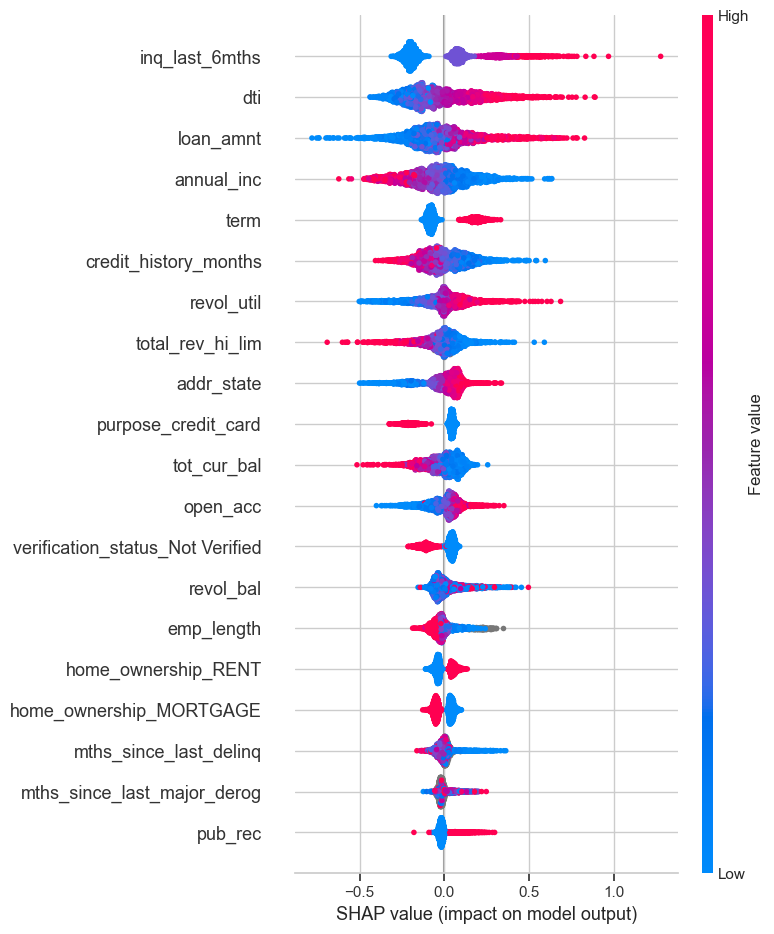

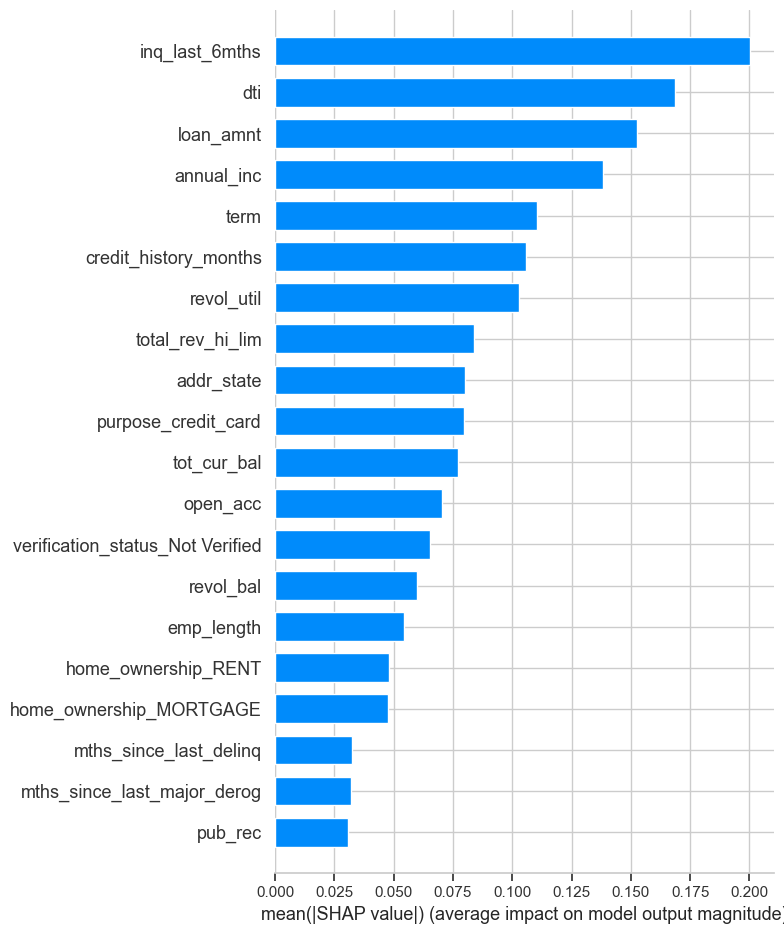

In [64]:
# Beeswarm: each dot is a loan; colour = feature value, x-position = push toward (right) / away from (left) default.
shap.summary_plot(shap_values, features=X_sample_t, feature_names=feat_names)

# Bar: mean |SHAP| = overall feature importance ranking.
shap.summary_plot(shap_values, features=X_sample_t, feature_names=feat_names, plot_type='bar')


**Global interpretation**
- The strongest drivers are recent credit applications (inq_last_6mths), debt-to-income, loan size, income, and loan term,exactly the signals expected to matter for repayment.
- The directions all make sense, which is the reassuring part. More recent credit applications, higher DTI, bigger loans, and higher card utilisation all push risk up; higher income, longer credit history, and a bigger credit limit push it down. So the model learned real, sensible patterns rather than noise.
- Recent credit-seeking is the single biggest signal. How many times someone applied for credit in the last 6 months matters most: a borrower chasing lots of new credit is the clearest warning sign.

### **5.2.5 Local interpretation (why one loan scored as it did)**

Loan with highest predicted risk: P(default) = 47.88%


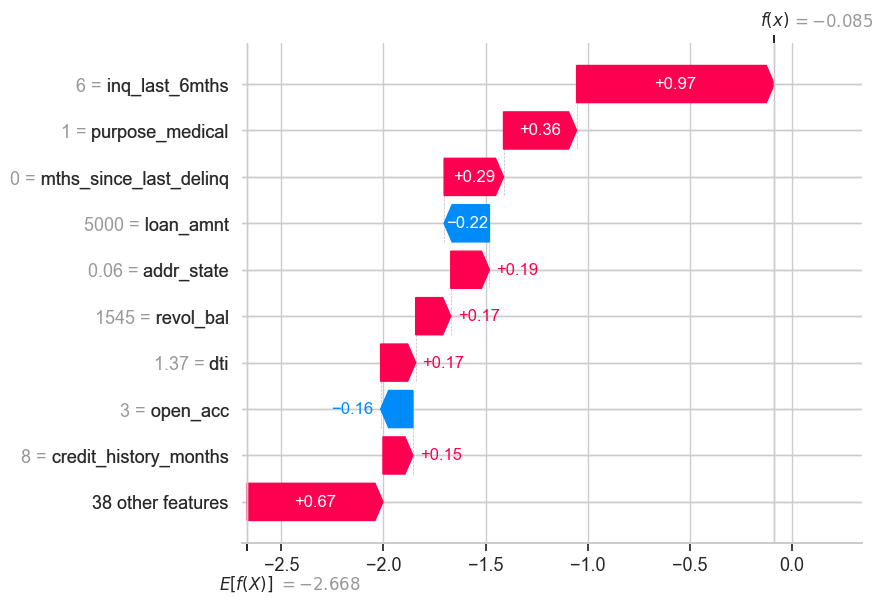

Loan with lowest predicted risk: P(default) = 0.45%


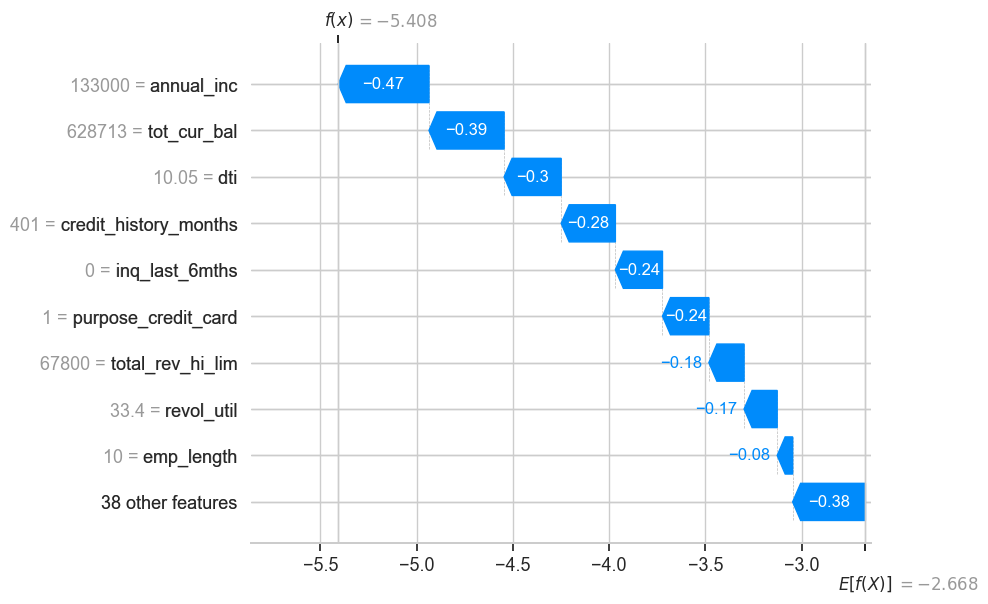

In [65]:
p = clf.predict_proba(X_sample_t)[:, 1]
hi, lo = p.argmax(), p.argmin()
for i, tag in [(hi, 'highest predicted risk'), (lo, 'lowest predicted risk')]:
    print(f"Loan with {tag}: P(default) = {p[i]:.2%}")
    shap.plots.waterfall(
        shap.Explanation(values=shap_values[i], base_values=explainer.expected_value,
                         data=X_sample_t[i], feature_names=feat_names)
    )


**Local interpretation**

- **The high-risk loan** is flagged mainly by 6 credit applications in the last 6 months (by far the biggest push up), a medical loan purpose, a recent missed payment, and a short credit history. A small loan amount pulls the risk down slightly, but nowhere near enough.
- **The low-risk loan** is the mirror image: a high income, a large existing balance, low DTI, a credit history over 30 years long, and no recent credit applications, all pushing the risk far down. This is the established, low-leverage borrower the model is most confident about.
- **The same few signals drive both loans**, just pointing opposite ways: recent applications, income, DTI, and credit history. So the individual explanations line up with the overall drivers, a sign the model is behaving consistently.

## **6. Conclusion**

### **6.1 Findings**

The pipeline produces an honest, leakage-free credit risk model built only from information available at the moment of application. On the held-out test sets, the tuned XGBoost reaches an AUC of about 0.67 (Gini ~0.35) on the random split and 0.66 (Gini ~0.32) on the 2016 out-of-time test. These figures are modest next to some Kaggle notebooks that report 0.90 or higher. That gap is most likely due to leakage in those notebooks: scores that high are typically only reachable when post-origination fields such as payments and recoveries are used as features, and those values are not available at the point of decision. For an at-application model with such fields removed, a score in this range looks like a more realistic expectation.

Three results stand out:

- **Tuning gave a small but consistent lift**, and helped the harder out-of-time case most (AUC 0.64 to 0.66), narrowing the gap between the two splits from about 0.018 to 0.013.
- **The drop on the 2016 test is small**, so the model holds up reasonably well on loans issued after the training period. A large gap would have signalled heavy reliance on the future resembling the past; the small gap is the reassuring case.
- **SHAP confirms the model learned sensible patterns**. The strongest drivers are recent credit applications, debt-to-income, loan size, income, and term, and each points in the direction a human underwriter would expect. That makes the model's decisions interpretable and justifiable, which matters for a lending system.

### **6.2 Limitations**
- **A 12-month window, not lifetime.** A loan counts as good once it survives its first 12 months, even if it defaults later, so the true lifetime default rate is higher than the 5.34% measured here.
- **Single-snapshot data.** Each source file is frozen at one date, which leaves 2015 represented only by its January loans and removes 2017 entirely. A deployed model would be retrained on rolling, more complete data.
- **Self-reported income.** Annual income is borrower-stated and only partly verified, so some values are noisy or inflated.
- **No segment-level stress testing.** Performance is reported in aggregate. Checking the model by cohort (loan size, region) is a recommended next step, since aggregate AUC can hide segments where the model is much weaker.

### **6.3 What carries forward to the Amplifi tradeline project**
The value of this walk-through is the reusable scaffolding. The following transfer directly:

- **Leakage discipline:** an explicit keep/drop audit that removes any field populated after origination.
- **A defined performance window:** the two-step labelling (observe a full window, then label) and the rule to keep only fully-observed loans.
- **Honest evaluation:** a random split for an optimistic baseline and an out-of-time split for the realistic one, compared directly.
- **Nested tuning:** StratifiedKFold cross-validation inside an Optuna search, with the test set untouched until the end.
- **Leakage-safe encoding:** target encoding fit only on training folds, inside the pipeline.
- **Interpretation:** SHAP for both global drivers and per-loan explanations.